# **STAGE 1: CLEAN DATA**

## 1.1 Upload Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from IPython.display import display, HTML

In [2]:
# from google.colab import drive  # Colab only
# drive.mount('/content/drive')  # Colab only

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
file_health = '../data/consumer_financial_health_engagement_2025.csv'
file_trans = '../data/consumer_transactions_2025.csv'

In [5]:
df_health = pd.read_csv(file_health)
obj_vars_health = df_health.select_dtypes(include=['object']).columns.tolist()
num_vars_health = df_health.select_dtypes(include=['number']).columns.tolist()

print("\nTHÔNG TIN BIẾN: consumer_financial_health_engagement_2025.csv")
print("-" * 50)
print(f"FILE 1: {file_health}")
print(f" - Tổng số cột : {df_health.shape[1]}")
print(f" - Số biến Object: {len(obj_vars_health)} -> {obj_vars_health}")
print(f" - Số biến Numeric: {len(num_vars_health)} -> {num_vars_health}")


THÔNG TIN BIẾN: consumer_financial_health_engagement_2025.csv
--------------------------------------------------
FILE 1: /content/drive/MyDrive/HCMUS/P/BUSINESS INTELEGENCE/BI10/ROUND_1/BI10_ROUND01_DATASET/consumer_financial_health_engagement_2025.csv
 - Tổng số cột : 30
 - Số biến Object: 7 -> ['consumer_id', 'analysis_month', 'gender', 'occupation', 'province_city', 'engagement_segment', 'financial_health_segment']
 - Số biến Numeric: 23 -> ['age', 'monthly_income_vnd', 'credit_limit_vnd', 'opening_balance_vnd', 'ending_balance_vnd', 'total_spend_vnd', 'essential_spend_vnd', 'discretionary_spend_vnd', 'online_spend_vnd', 'transaction_count', 'active_transaction_days', 'average_transaction_value_vnd', 'category_diversity', 'essential_spend_ratio', 'discretionary_spend_ratio', 'online_spend_ratio', 'spend_to_income_ratio', 'credit_utilization_ratio', 'transaction_recency_days', 'spending_volatility', 'engagement_score', 'financial_health_score', 'next_month_low_health_flag']


In [6]:
df_trans = pd.read_csv(file_trans)
obj_vars_trans = df_trans.select_dtypes(include=['object']).columns.tolist()
num_vars_trans = df_trans.select_dtypes(include=['number']).columns.tolist()

print("\nTHÔNG TIN BIẾN: consumer_transactions_2025.csv")
print("-" * 50)
print(f"FILE 2: {file_trans}")
print(f" - Tổng số cột : {df_trans.shape[1]}")
print(f" - Số biến Object: {len(obj_vars_trans)} -> {obj_vars_trans}")
print(f" - Số biến Numeric: {len(num_vars_trans)} -> {num_vars_trans}")


THÔNG TIN BIẾN: consumer_transactions_2025.csv
--------------------------------------------------
FILE 2: /content/drive/MyDrive/HCMUS/P/BUSINESS INTELEGENCE/BI10/ROUND_1/BI10_ROUND01_DATASET/consumer_transactions_2025.csv
 - Tổng số cột : 28
 - Số biến Object: 15 -> ['transaction_id', 'activity_datetime', 'consumer_id', 'customer_name', 'gender', 'date_of_birth', 'occupation', 'street_address', 'ward_commune', 'province_city', 'merchant_id', 'merchant_name', 'spending_category', 'transaction_channel', 'payment_method']
 - Số biến Numeric: 13 -> ['age_at_transaction', 'administrative_code', 'customer_latitude', 'customer_longitude', 'local_population', 'spend_amount_vnd', 'merchant_latitude', 'merchant_longitude', 'online_transaction_flag', 'essential_spending_flag', 'transaction_month', 'transaction_day_of_week', 'transaction_hour']


## 1.2 Transaction level

In [ ]:
# 1. Kiểm tra tính toàn vẹn cấu trúc
# 1.1 Kiểm tra toàn vẹn khóa chính:
total_rows_trans = len(df_trans) # Tổng số dòng
unique_transaction_ids = df_trans['transaction_id'].nunique() # Số lượng bản ghi duy nhất
expected_count = 1852394 # Expect: Tổng số dòng = Số bản ghi duy nhất = 1852394

print(f"Tổng số bản ghi vật lý : {total_rows_trans:,}")
print(f"Số lượng transaction_id duy nhất : {unique_transaction_ids:,}")
print("-" * 50)

if unique_transaction_ids == expected_count and total_rows_trans == expected_count:
    print("[PASS] - Khóa chính hoàn toàn duy nhất. Volume khớp chính xác tuyệt đối 1,852,394 bản ghi.")
else:
    print(f"[FAIL] - Phát hiện bất thường trong Khóa chính.")
    print(f"Độ lệch: {unique_transaction_ids - expected_count:,} bản ghi")

Tổng số bản ghi vật lý : 1,852,394
Số lượng transaction_id duy nhất : 1,852,394
--------------------------------------------------
[PASS] - Khóa chính hoàn toàn duy nhất. Volume khớp chính xác tuyệt đối 1,852,394 bản ghi.


In [ ]:
## 1.2 Kiểm tra trùng lặp
subset = ['consumer_id', 'merchant_id', 'activity_datetime', 'spend_amount_vnd']

# Gom nhóm theo cụm biến, đếm số lượng bản ghi cho mỗi cụm
dup_summary = df_trans.groupby(subset, dropna=False).size().reset_index(name='record_count')

# Lọc ra các cụm có tần suất > 1 (nghĩa là bị trùng) và sắp xếp giảm dần
logic_duplicates = dup_summary[dup_summary['record_count'] > 1].sort_values(by='record_count', ascending=False)

if not logic_duplicates.empty:
    print(f"[CẢNH BÁO] Phát hiện {len(logic_duplicates):,} cụm giá trị unique bị ghi đè trùng lặp:")
    display(logic_duplicates)
else:
    print("[PASS] Không phát hiện trùng lặp logic.")

[PASS] Không phát hiện trùng lặp logic.


In [ ]:
# 2. Kiểm tra tính toàn vẹn dữ liệu
## 2.1 Phát hiện Explicit Missing (NULL)

# Tính tỷ lệ % khuyết thiếu và chuyển thành DataFrame
missing_pct = (df_trans.isna().mean() * 100).round(4)

# Lọc các biến có NULL, sắp xếp giảm dần để ưu tiên xử lý
explicit_missing = missing_pct[missing_pct > 0].sort_values(ascending=False).reset_index()
explicit_missing.columns = ['Biến (Column)', 'Tỷ lệ Khuyết (%)']

if not explicit_missing.empty:
    print(f"[CẢNH BÁO] Phát hiện {len(explicit_missing)}/28 cột bị thủng dữ liệu (Khuyết mở):")
    display(explicit_missing)
else:
    print("[PASS] Toàn vẹn 100%. Không phát hiện giá trị NULL (Khuyết mở) trên toàn bộ 28 cột.")

[PASS] Toàn vẹn 100%. Không phát hiện giá trị NULL (Khuyết mở) trên toàn bộ 28 cột.


In [ ]:
## 2.2 Phát hiện Implicit Missing (ký tự đại diện cho dữ liệu khuyết): Kiểm tra cho các biến object
suspect_strings = ['không', 'không xác định', 'unknown', 'null', 'nan', 'none', 'n/a', 'undefined', '', ' ']

# Object chứa giá trị trong suspect_strings -> khuyết
obj_issues = (
    df_trans[obj_vars_trans]
    .apply(
        lambda col: (
            col.astype('string')
            .str.strip()
            .str.lower()
            .isin(suspect_strings)
        ).sum()
    )
)

# Chuyển thành DataFrame
implicit_summary = (
    obj_issues
    .rename('Số lượng Khuyết Ẩn')
    .reset_index()
)

implicit_summary.columns = [
    'Biến (Column)',
    'Số lượng Khuyết Ẩn'
]

# Giữ các biến có khuyết
implicit_missing = (
    implicit_summary[
        implicit_summary['Số lượng Khuyết Ẩn'] > 0
    ]
    .copy()
)

# Tính % lỗi
if not implicit_missing.empty:
  implicit_missing['Tỷ lệ (%)'] = (implicit_missing['Số lượng Khuyết Ẩn'] / len(df_trans) * 100).round(4)
  implicit_missing = implicit_missing.sort_values(by='Số lượng Khuyết Ẩn', ascending=False)
  print(f"[FAIL] Phát hiện {len(implicit_missing)} cột có dữ liệu rác/khuyết ẩn (Implicit Missing):")
  display(implicit_missing)
else:
  print("[PASS] Không phát hiện giá trị âm (<0) hoặc chuỗi vô nghĩa.")

[PASS] Không phát hiện giá trị âm (<0) hoặc chuỗi vô nghĩa.


In [ ]:
# So khớp số lượng tỉnh thành
unique_province_cities = df_trans['province_city'].nunique()
expected_province_count = 34

print(f"Số lượng tỉnh/thành phố duy nhất: {unique_province_cities}")

if unique_province_cities == expected_province_count:
    print(f"[PASS] Số lượng tỉnh/thành phố duy nhất khớp với {expected_province_count}.")
else:
    print(f"[FAIL] Số lượng tỉnh/thành phố duy nhất không khớp. Expected: {expected_province_count}, Found: {unique_province_cities}.")

Số lượng tỉnh/thành phố duy nhất: 34
[PASS] Số lượng tỉnh/thành phố duy nhất khớp với 34.


In [ ]:
# 1. Định nghĩa Rule Engine (Điều kiện chuẩn: Trả về True nếu HỢP LỆ)

domain_rules = {
    'transaction_id': lambda s: s.str.match(r'^GD2025\d{10}$', na=False),
    'activity_datetime': lambda s: pd.to_datetime(s, errors='coerce').dt.year == 2025, # Ép kiểu on-the-fly để check năm
    'consumer_id': lambda s: s.str.match(r'^KH\d{8}$', na=False),
    'gender': lambda s: s.isin(['Nam', 'Nữ']),
    'age_at_transaction': lambda s: s.between(14, 96),
    'province_city': lambda s: s.notna() & (s != ''), # Cần inject danh sách 34 tỉnh thành thực tế vào isin() nếu có
    'administrative_code': lambda s: s.astype(str).str.match(r'^\d{5}$', na=False), # Mã hành chính 5 chữ số
    'customer_latitude': lambda s: s.between(8.0, 23.6),
    'customer_longitude': lambda s: s.between(102.0, 110.0),
    'local_population': lambda s: s > 2000,
    'merchant_id': lambda s: s.str.match(r'^M\d{5}$', na=False),
    'spending_category': lambda s: s.notna() & (s != ''), # Cần inject danh sách 14 categories thực tế vào isin() nếu có
    'spend_amount_vnd': lambda s: s >= 0,
    'merchant_latitude': lambda s: s.between(8.0, 23.6),
    'merchant_longitude': lambda s: s.between(102.0, 110.0),
    'transaction_channel': lambda s: s.isin(['POS', 'E-commerce', 'Mobile App', 'QR Payment', 'Recurring Payment']),
    'payment_method': lambda s: s.isin(['Thẻ tín dụng', 'Thẻ ghi nợ', 'Ví điện tử', 'Chuyển khoản', 'QR']),
    'online_transaction_flag': lambda s: s.isin([0, 1]),
    'essential_spending_flag': lambda s: s.isin([0, 1]),
    'transaction_month': lambda s: s.between(1, 12),
    'transaction_day_of_week': lambda s: s.between(0, 6),
    'transaction_hour': lambda s: s.between(0, 23)
}

# 2. Quét Vectorized & Bóc tách lỗi
violation_report = []
valid_mask_total = pd.Series(True, index=df_trans.index) # Khởi tạo mask giữ dòng đúng

for col, rule in domain_rules.items():
    if col in df_trans.columns:
        # Nhận diện dòng VI PHẠM: sai rule & không phải là NULL (để tách bạch với khuyết thiếu)
        invalid_mask = ~rule(df_trans[col]) & df_trans[col].notnull()

        # Cập nhật mask tổng (Chỉ giữ lại các dòng False của invalid_mask)
        valid_mask_total &= ~invalid_mask

        violation_count = invalid_mask.sum()
        if violation_count > 0:
            # Lấy 10 mẫu giá trị sai thực tế để định hướng fix bug
            bad_samples = df_trans.loc[invalid_mask, col].unique()[:5]
            violation_report.append({
                'Biến (Column)': col,
                'Số dòng vi phạm': violation_count,
                'Giá trị sai (Mẫu)': list(bad_samples)
            })

# 3. Báo cáo & Khởi tạo luồng lọc dữ liệu
if violation_report:
    df_violations = pd.DataFrame(violation_report).sort_values(by='Số dòng vi phạm', ascending=False)
    print(f"[FAIL] Phát hiện {len(df_violations)} biến chứa giá trị ngoài miền quy định:")
    display(df_violations)

    # Action: Ép kiểu giữ lại dataframe sạch (Lọc bỏ các bản ghi vi phạm logic)
    df_trans_clean = df_trans[valid_mask_total].copy()
    print(f"\nĐã lọc {len(df_trans) - len(df_trans_clean):,} dòng vi phạm. Dữ liệu chuẩn còn lại: {len(df_trans_clean):,} dòng.")
else:
    print("[PASS] Toàn bộ dữ liệu tuân thủ nghiêm ngặt miền giá trị.")
    df_trans_clean = df_trans.copy()

[FAIL] Phát hiện 1 biến chứa giá trị ngoài miền quy định:


,Biến (Column),Số dòng vi phạm,Giá trị sai (Mẫu)
0,administrative_code,190952,"[8288, 8182, 1680, 1778, 1019]"



Đã lọc 190,952 dòng vi phạm. Dữ liệu chuẩn còn lại: 1,661,442 dòng.


In [ ]:
# Kiểm tra so khớp
display(df_trans[['province_city', 'ward_commune', 'administrative_code']].head())

,province_city,ward_commune,administrative_code
0,Đắk Lắk,Tân Lập,66661
1,Lạng Sơn,Bắc Sơn,20965
2,Thành phố Hồ Chí Minh,Gò Vấp,79017
3,Sơn La,Chiềng Sinh,14085
4,Nghệ An,Vinh Tân,40195


> **Note**
- administrative_code:  Mã tỉnh và mã quận/huyện theo chuẩn cũ của Tổng cục Thống kê
  - 2 chữ số đầu là mã định danh Tỉnh / Thành phố trực thuộc trung ướng
  - 3 chữ số cuối là mã Quận/Huyện thuộc tỉnh

In [ ]:
display(df_trans.loc[df_trans['administrative_code'].astype(str).str.len() != 5, ['province_city', 'ward_commune', 'administrative_code']])

,province_city,ward_commune,administrative_code
13,Tuyên Quang,Yên Sơn,8288
27,Tuyên Quang,Yên Sơn,8182
85,Hà Nội,Hà Đông,1680
88,Hà Nội,Hoàng Mai,1778
90,Hà Nội,Ba Đình,1019
...,...,...,...
1852363,Hà Nội,Gia Lâm,1947
1852364,Hà Nội,Gia Lâm,1539
1852367,Hà Nội,Nam Từ Liêm,1908
1852372,Hà Nội,Gia Lâm,1947


In [ ]:
# 4. Kiểm tra tính nhất quán
## 4.1 Kiểm tra activity_time với các biến phái sinh transaction_month, transaction_day_of_week, transaction_hour

In [ ]:
## 4.2 Kiểm tra age_at_transaction với date_of_birth

In [ ]:
## 4.3 Kiểm tra transaction_channel với online_transaction_flag: Nếu transaction_channel là E-commerce hoặc Mobile App, thì online_transaction_flag bắt buộc phải bằng 1, ngược lại bằng 0

In [ ]:
## 4.4 Đối chiếu spending_category và essential_spending_flag: Lọc các danh mục thiết yếu, và danh mục không thiết yếu

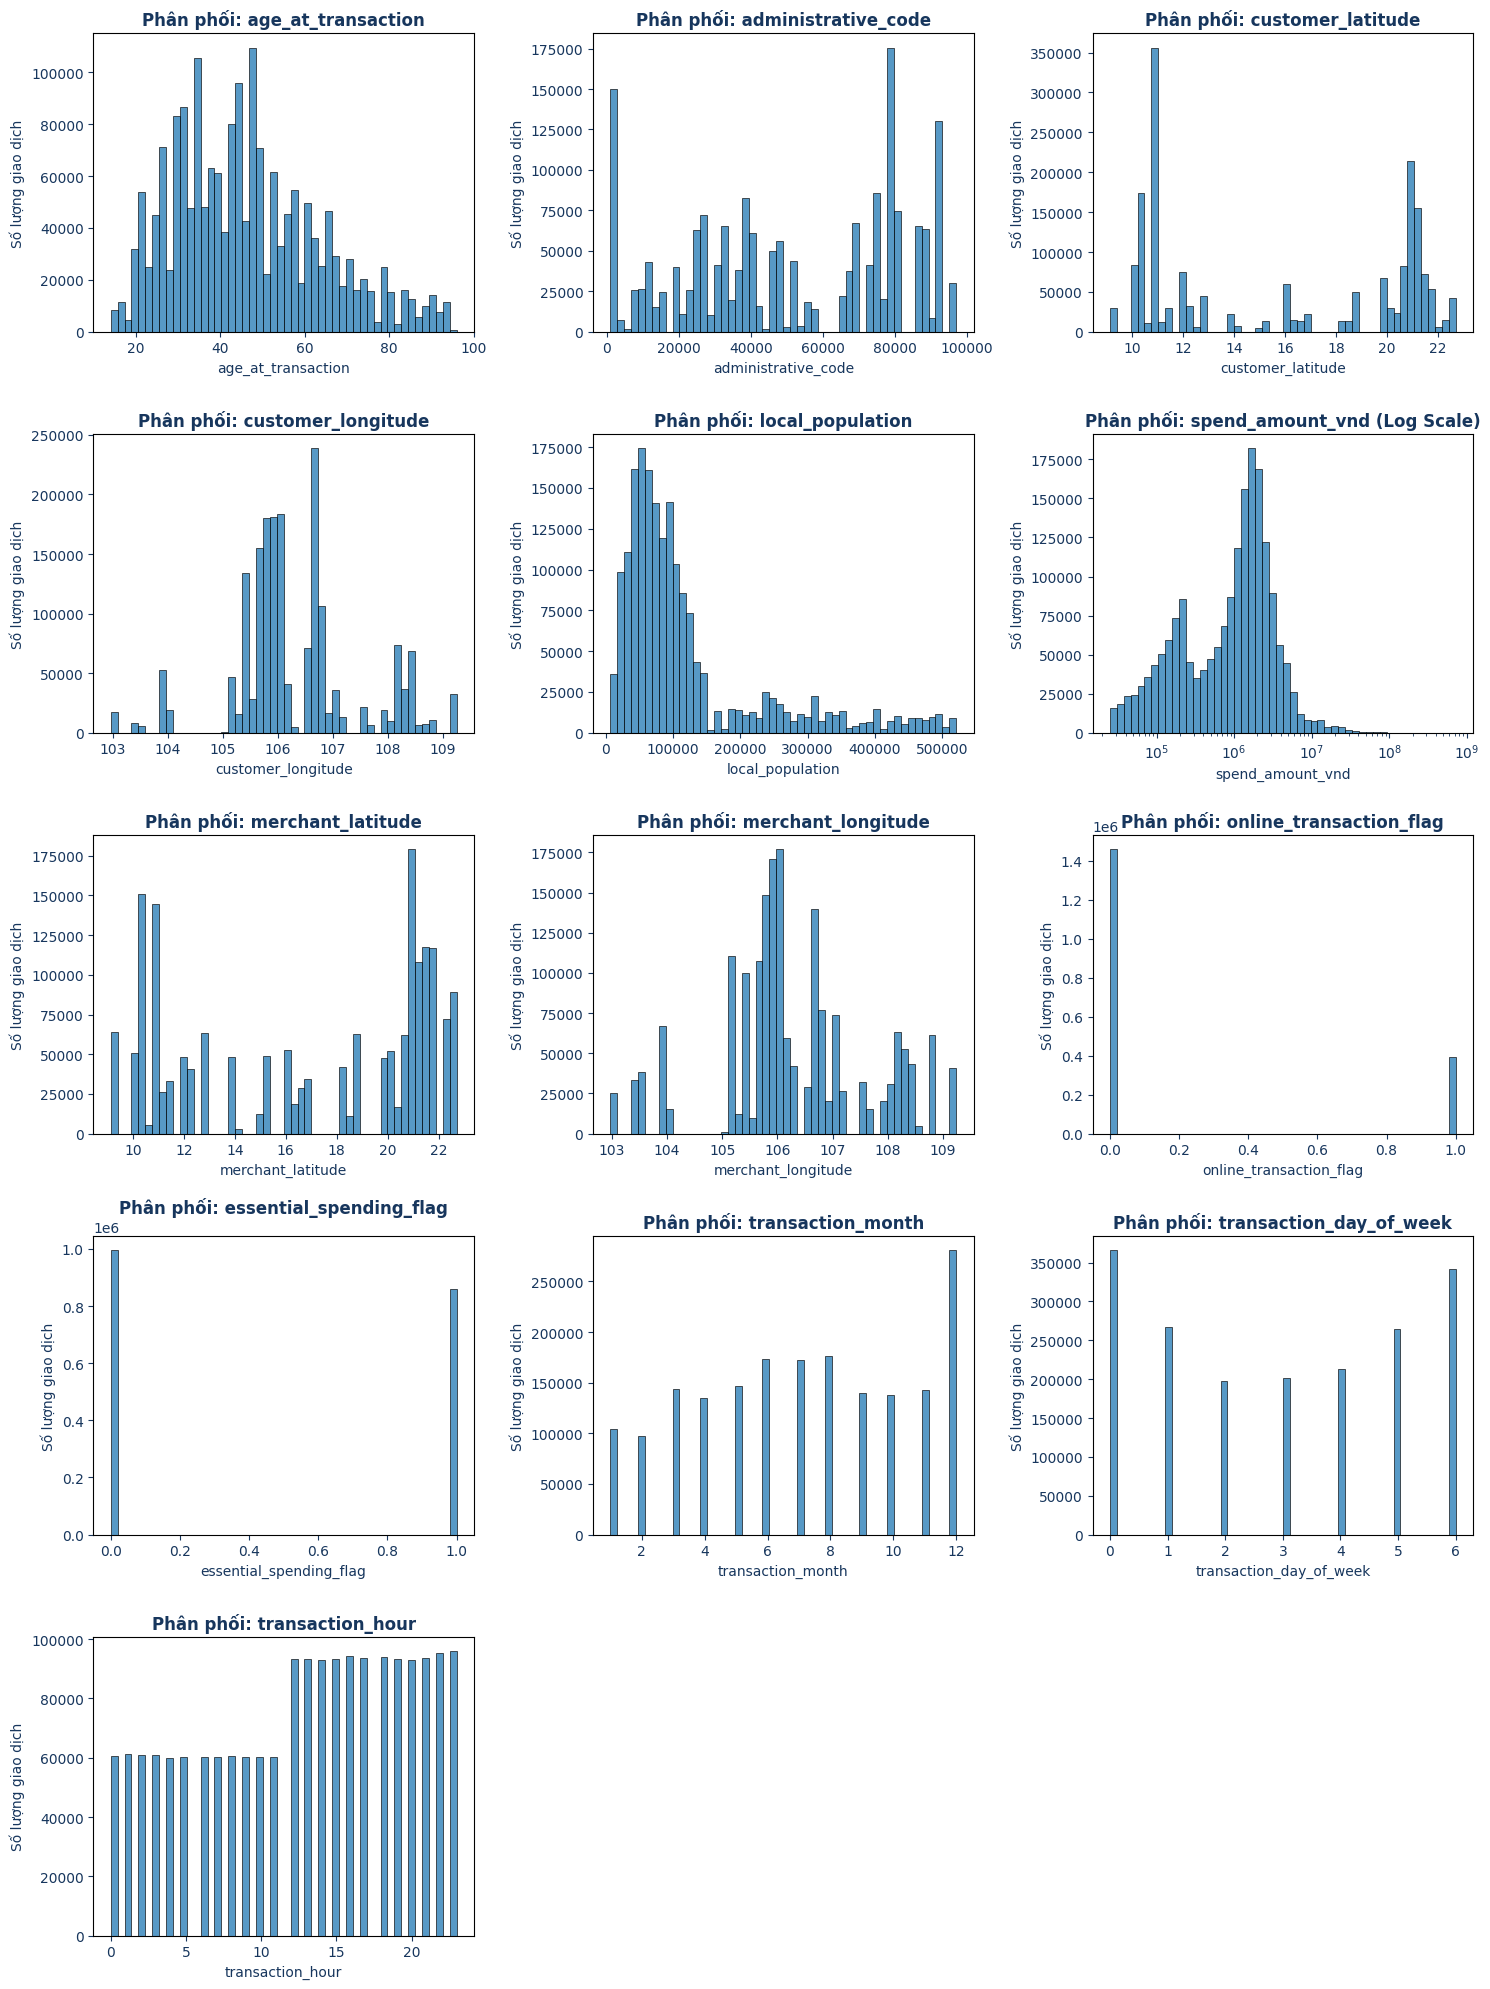

In [ ]:
# 5. Kiểm tra phân phối
# 5.1 Phân phối của các biến số: spend_amount_vnd, age_at_transaction và các biến số khác
num_cols_to_plot = num_vars_trans

# Dynamically determine the grid size
num_plots = len(num_cols_to_plot)
ncols = 3  # Number of columns in the subplot grid
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

for i, col in enumerate(num_cols_to_plot):
    # Dùng log-scale cho spend_amount_vnd nếu dữ liệu lệch phải quá mạnh (Right-skewed)
    log_scale = True if col == 'spend_amount_vnd' else False

    sns.histplot(
        df_trans[col],
        bins=50,
        kde=False,
        log_scale=log_scale,
        ax=axes[i],
        color='#1f77b4'
    )

    title = f'Phân phối: {col} (Log Scale)' if log_scale else f'Phân phối: {col}'
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_ylabel('Số lượng giao dịch')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:

# 5.2 Phân phối của các biến object: spending_category, transaction_channel và các biến object khác
cat_cols_to_plot = obj_vars_trans

# Dynamically determine the grid size
num_plots = len(cat_cols_to_plot)
ncols = 3 # Number of columns in the subplot grid
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

for i, col in enumerate(cat_cols_to_plot):
    # Tiền tổng hợp dữ liệu (O(N) data -> O(1) plot)
    cat_summary = df_trans[col].value_counts().reset_index()
    cat_summary.columns = [col, 'count']

    sns.barplot(
        x='count',
        y=col,
        data=cat_summary,
        ax=axes[i],
        palette='viridis'
    )

    axes[i].set_title(f'Tần suất Giao dịch: {col}', fontweight='bold')
    axes[i].set_xlabel('Số lượng giao dịch')
    axes[i].set_ylabel('')

    # Add exact values on the bars
    for index, row in cat_summary.iterrows():
        axes[i].text(row['count'], index, f'{row['count']:,}', color='black', ha="left", va="center")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipykernel_3930/143747359.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


## 1.3 Consumer-Month Level

# **STAGE 2: Macro Temporal Analysis**

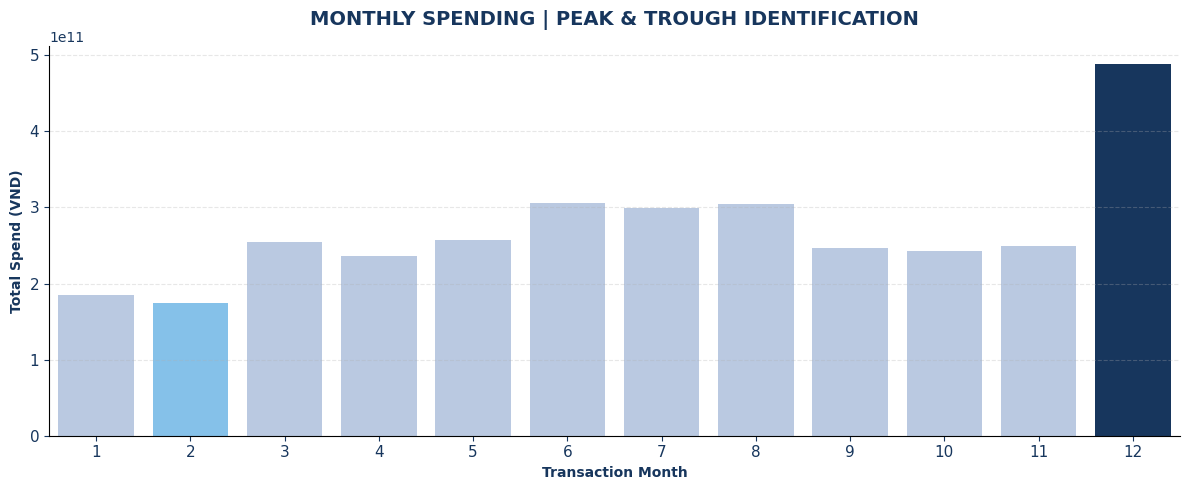

In [7]:
# TÌM THÁNG CHI TIÊU CAO NHẤT VÀ THẤP NHẤT
# ==============================================================================

# 1. Tính tổng chi tiêu theo tháng (Transaction Level)
monthly_spend = (
    df_trans
    .groupby('transaction_month', as_index=False)['spend_amount_vnd']
    .sum()
)

# Xác định Tháng Đỉnh (Peak) và Tháng Đáy (Trough)
peak_idx = monthly_spend['spend_amount_vnd'].idxmax()
trough_idx = monthly_spend['spend_amount_vnd'].idxmin()

peak_month = monthly_spend.loc[peak_idx]
trough_month = monthly_spend.loc[trough_idx]

# 2. Tính tổng chi tiêu cả năm (Consumer-Month Level)
annual_spend_health = df_health['total_spend_vnd'].sum()

# 3. Tính tỷ trọng % so với cả năm
peak_pct = (
    peak_month['spend_amount_vnd'] / annual_spend_health
) * 100

trough_pct = (
    trough_month['spend_amount_vnd'] / annual_spend_health
) * 100

# ==============================================================================
# TRỰC QUAN HÓA (VISUALIZATION) - UNIFIED DARK BLUE THEME
# ==============================================================================

plt.figure(figsize=(12, 5))

# Toàn bộ cột thường dùng màu xanh nhạt dịu #B4C7E7
ax = sns.barplot(
    data=monthly_spend,
    x='transaction_month',
    y='spend_amount_vnd',
    color='#B4C7E7'
)

# Highlight Peak (Thành màu xanh thương hiệu đậm #17365D) & Trough (Màu xanh dương tươi #85c1e9)
ax.patches[peak_idx].set_facecolor('#17365D')    # Dark blue: Peak
ax.patches[trough_idx].set_facecolor('#85c1e9')  # Bright light blue: Trough

# Thiết lập nhãn trục và tiêu đề đồng màu thương hiệu #17365D
plt.title(
    'MONTHLY SPENDING | PEAK & TROUGH IDENTIFICATION',
    fontweight='bold',
    fontsize=14,
    pad=15,
    color='#17365D'
)

plt.xlabel(
    'Transaction Month',
    fontweight='bold',
    color='#17365D'
)

plt.ylabel(
    'Total Spend (VND)',
    fontweight='bold',
    color='#17365D'
)

ax.tick_params(colors='#17365D', labelsize=11)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

sns.despine()
plt.tight_layout()
plt.show()

# ==============================================================================
# OUTPUT REPORT — PEAK MONTH & TROUGH MONTH
# ==============================================================================

html_report = f"""
<div style="
    font-family: Arial, sans-serif;
    border: 1px solid #D9E2F3;
    border-radius: 8px;
    padding: 20px;
    max-width: 700px;
    background-color: #FFFFFF;
">

    <!-- MAIN TITLE -->
    <h3 style="
        color: #17365D;
        border-bottom: 2px solid #17365D;
        padding-bottom: 8px;
        margin-top: 0;
        margin-bottom: 8px;
        font-size: 18px;
        letter-spacing: 0.3px;
    ">
        PEAK MONTH &amp; TROUGH MONTH
    </h3>

    <!-- ANNUAL TOTAL -->
    <p style="
        font-size: 13px;
        color: #5B6573;
        margin-bottom: 20px;
    ">
        Annual Total Spend:
        <strong style="
            color: #17365D;
            font-size: 15px;
        ">
            {annual_spend_health:,.0f} VND
        </strong>
    </p>


    <!-- CARDS -->
    <div style="
        display: flex;
        justify-content: space-between;
        gap: 15px;
    ">

        <!-- PEAK CARD -->
        <div style="
            flex: 1;
            background: #EAF2F8;
            border-left: 5px solid #17365D;
            padding: 14px;
            border-radius: 4px;
        ">

            <div style="
                font-weight: bold;
                color: #17365D;
                font-size: 13px;
                text-transform: uppercase;
                letter-spacing: 0.4px;
            ">
                PEAK MONTH
            </div>

            <div style="
                font-size: 23px;
                font-weight: bold;
                color: #17365D;
                margin: 8px 0;
            ">
                Month {int(peak_month['transaction_month'])}
            </div>

            <div style="
                font-size: 13px;
                color: #4F5965;
                line-height: 1.7;
            ">
                Total Spend:
                <b style="color: #17365D;">
                    {peak_month['spend_amount_vnd']:,.0f} VND
                </b>
                <br>

                Annual Share:
                <b style="color: #17365D;">
                    {peak_pct:.2f}%
                </b>
            </div>

        </div>


        <!-- TROUGH CARD -->
        <div style="
            flex: 1;
            background: #F4F8FC;
            border-left: 5px solid #85c1e9;
            padding: 14px;
            border-radius: 4px;
        ">

            <div style="
                font-weight: bold;
                color: #85c1e9;
                font-size: 13px;
                text-transform: uppercase;
                letter-spacing: 0.4px;
            ">
                TROUGH MONTH
            </div>

            <div style="
                font-size: 23px;
                font-weight: bold;
                color: #17365D;
                margin: 8px 0;
            ">
                Month {int(trough_month['transaction_month'])}
            </div>

            <div style="
                font-size: 13px;
                color: #4F5965;
                line-height: 1.7;
            ">
                Total Spend:
                <b style="color: #17365D;">
                    {trough_month['spend_amount_vnd']:,.0f} VND
                </b>
                <br>

                Annual Share:
                <b style="color: #85c1e9;">
                    {trough_pct:.2f}%
                </b>
            </div>

        </div>

    </div>

</div>
"""

display(HTML(html_report))

> **Markdown**

- December records the highest spend at VND 488.03B (15.04% of annual spend), versus February at VND 174.37B (5.37%), the lowest.
December therefore captures nearly 3× February’s share of annual spending, indicating pronounced seasonal concentration.

,Delta (%),12,2
Total Spend (VND),179.89%,"488,032,709,000.00","174,365,111,000.00"
Transaction Volume,187.33%,"280,598.00","97,657.00"
Average Ticket Size (VND),-2.59%,"1,739,259.40","1,785,485.02"
Median Ticket Size (VND),-1.66%,"1,182,000.00","1,202,000.00"


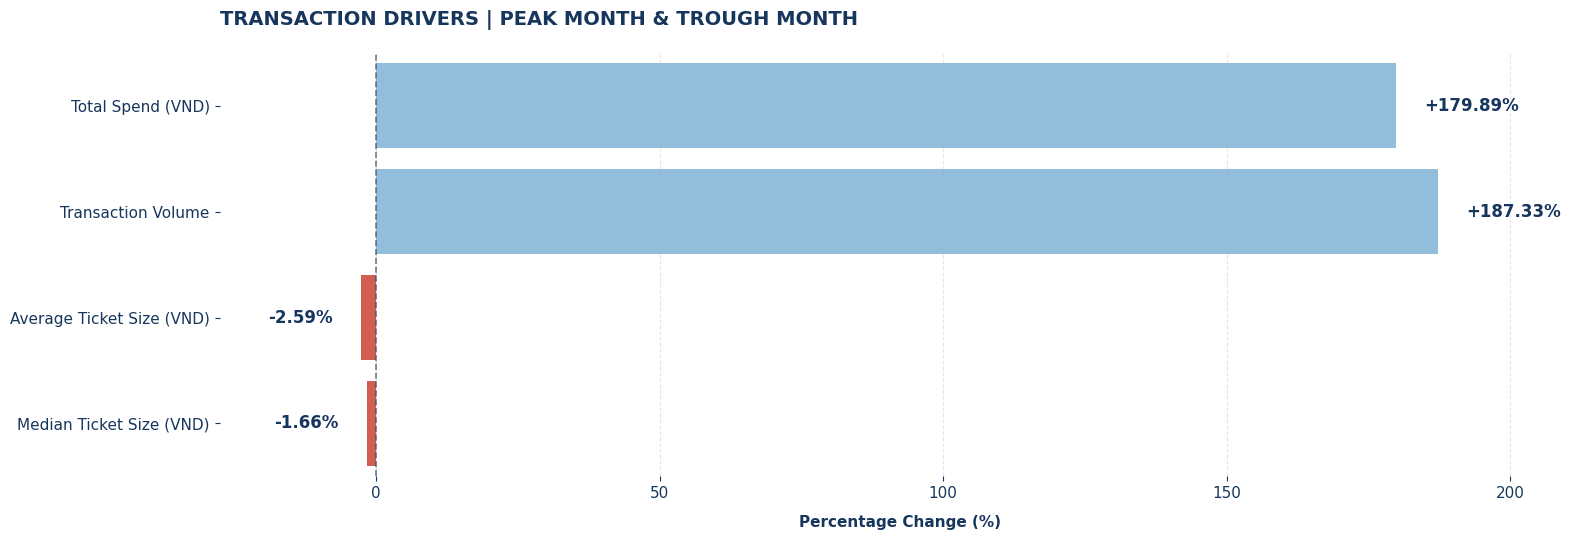

In [8]:
# TÌM NGUYÊN NHÂN CHO THÁNG CHI TIÊU NHIỀU
# ==============================================================================
# BƯỚC 2.2A: BÓC TÁCH ĐỘNG LỰC TĂNG TRƯỞNG (TRANSACTION LEVEL)
# LƯỚI BẢO VỆ: Volume & Ticket Size
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ------------------------------------------------------------------------------
# 1. Tính toán ma trận động lực theo tháng
# ------------------------------------------------------------------------------
trans_drivers = df_trans.groupby('transaction_month').agg(
    total_spend=('spend_amount_vnd', 'sum'),
    volume_count=('transaction_id', 'count'),
    ticket_mean=('spend_amount_vnd', 'mean'),
    ticket_median=('spend_amount_vnd', 'median')
)

# ------------------------------------------------------------------------------
# 2. Tự động xác định Tháng Đỉnh & Tháng Đáy
# ------------------------------------------------------------------------------
peak_m = trans_drivers['total_spend'].idxmax()
trough_m = trans_drivers['total_spend'].idxmin()

# ------------------------------------------------------------------------------
# 3. Tính Delta (%)
# ------------------------------------------------------------------------------
compare_trans = trans_drivers.loc[[peak_m, trough_m]].T

compare_trans['Delta (%)'] = (
    (compare_trans[peak_m] - compare_trans[trough_m])
    / compare_trans[trough_m] * 100
)

# ------------------------------------------------------------------------------
# 4. Đổi tên chỉ tiêu
# ------------------------------------------------------------------------------
compare_trans.index = [
    'Total Spend (VND)',
    'Transaction Volume',
    'Average Ticket Size (VND)',
    'Median Ticket Size (VND)'
]

# Đưa Delta lên đầu để nhấn mạnh mức thay đổi
compare_trans_final = compare_trans[
    ['Delta (%)', peak_m, trough_m]
]

# Loại bỏ tên trục chỉ mục để góc trên bên trái trống hoàn toàn
compare_trans_final.index.name = None
compare_trans_final.columns.name = None

# ------------------------------------------------------------------------------
# 5. Styled Table
# ------------------------------------------------------------------------------
styled_table = (
    compare_trans_final.style

    # ===== TIÊU ĐỀ =====
    .set_caption(
        f"TRANSACTION DRIVERS  |  PEAK MONTH (M{int(peak_m)}) vs. TROUGH MONTH (M{int(trough_m)})"
    )

    # ===== FORMAT SỐ =====
    .format({
        'Delta (%)': '{:,.2f}%',
        peak_m: '{:,.2f}',
        trough_m: '{:,.2f}'
    })

    # ===== STYLE =====
    .set_table_styles([

        # --- Tiêu đề bảng ---
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-family', 'Arial, sans-serif'),
                ('font-size', '17px'),
                ('font-weight', 'bold'),
                ('color', '#17365D'),
                ('text-align', 'left'),
                ('padding', '0px 0px 12px 0px'),
                ('letter-spacing', '0.3px')
            ]
        },

        # --- Header ---
        {
            'selector': 'th.col_heading',
            'props': [
                ('background-color', '#17365D'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('border', '1px solid #D9E2F3'),
                ('padding', '10px 14px'),
                ('font-size', '13px')
            ]
        },

        # --- Nội dung bảng ---
        {
            'selector': 'td',
            'props': [
                ('color', '#17365D'),
                ('border', '1px solid #D9E2F3'),
                ('padding', '9px 14px'),
                ('font-size', '13px')
            ]
        },

        # --- Tên chỉ tiêu ---
        {
            'selector': 'th.row_heading',
            'props': [
                ('background-color', '#EAF2F8'),
                ('color', '#17365D'),
                ('font-weight', 'bold'),
                ('text-align', 'left'),
                ('border', '1px solid #D9E2F3'),
                ('padding', '9px 14px'),
                ('font-size', '13px')
            ]
        }
    ])

    # ===== TÔ ĐẬM SỐ LIỆU PEAK & TROUGH =====
    .set_properties(
        subset=[peak_m, trough_m],
        **{
            'font-weight': 'bold',
            'text-align': 'right'
        }
    )

    # ===== NHẤN MẠNH DELTA =====
    .set_properties(
        subset=['Delta (%)'],
        **{
            'font-weight': 'bold',
            'color': '#1F4E79',
            'background-color': '#D9EAF7',
            'text-align': 'right'
        }
    )

    # ===== CĂN GIỮA THEO CHIỀU DỌC =====
    .set_properties(
        **{
            'vertical-align': 'middle'
        }
    )

    # ===== KÍCH THƯỚC & ĐƯỜNG VIỀN =====
    .set_table_attributes(
        'style="'
        'border-collapse:collapse; '
        'width:100%; '
        'font-family:Arial, sans-serif; '
        'border:1px solid #B4C7E7;'
        '"'
    )
)

display(styled_table)
print("\n")

# ==============================================================================
# 6. PPT VISUALIZATION (WIDE CANVAS - ENG ONLY)
# ==============================================================================
plt.figure(figsize=(16, 5.5))

# Trích xuất dữ liệu delta để vẽ ngang
plot_data = compare_trans['Delta (%)'].reset_index()
plot_data.columns = ['Metric', 'Delta (%)']

# Sử dụng tông màu đồng nhất: positive = #85c1e9 (Light Blue), negative = #e74c3c
colors = ['#e74c3c' if x < 0 else '#85c1e9' for x in plot_data['Delta (%)']]

ax = sns.barplot(data=plot_data, x='Delta (%)', y='Metric', palette=colors, hue='Metric', legend=False)

# Đường mốc phân cách 0%
plt.axvline(0, color='#34495e', linestyle='--', linewidth=1.2, alpha=0.7)

# Thêm nhãn trực tiếp trên đầu thanh bar sử dụng màu #17365D
for index, row in plot_data.iterrows():
    val = row['Delta (%)']
    align = 'right' if val < 0 else 'left'
    offset = -5.0 if val < 0 else 5.0
    ax.text(val + offset, index, f"{val:+.2f}%",
            va='center', ha=align, fontweight='bold', fontsize=12, color='#17365D')

# Thiết lập tiêu đề Tiếng Anh chính xác, không thừa từ "month"
plt.title('TRANSACTION DRIVERS | PEAK MONTH & TROUGH MONTH',
          fontweight='bold', fontsize=14, color='#17365D', pad=20, loc='left')

plt.xlabel('Percentage Change (%)', fontweight='bold', fontsize=11, labelpad=10, color='#17365D')
plt.ylabel('', fontsize=11)
plt.xlim(plot_data['Delta (%)'].min() - 25, plot_data['Delta (%)'].max() + 25)

# Đồng bộ màu sắc nhãn trục tọa độ về #17365D
ax.tick_params(colors='#17365D', labelsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

- Total Spend surged by 179.89% purely as a function of exploding Transaction Volume (+187.33%), completely diverging from the marginal contractions in both Average (-2.59%) and Median (-1.66%) Ticket Sizes, with their similar movements indicating a broad-based softening in transaction value rather than a tail-driven effect. Behaviorally, this structural shift indicates the revenue uplift is driven by high-frequency, fragmented purchasing rather than premium or bulk buying, with the broadly consistent ticket-size contraction suggesting that spending intensity per transaction remained stable-to-weaker across the customer base

,Delta (%),12,2
Active Users,-0.11%,918.00,919.00
Avg. Active Transaction Days,20.10%,30.39,25.30
Avg. Spending Volatility,19.26%,1.73,1.45


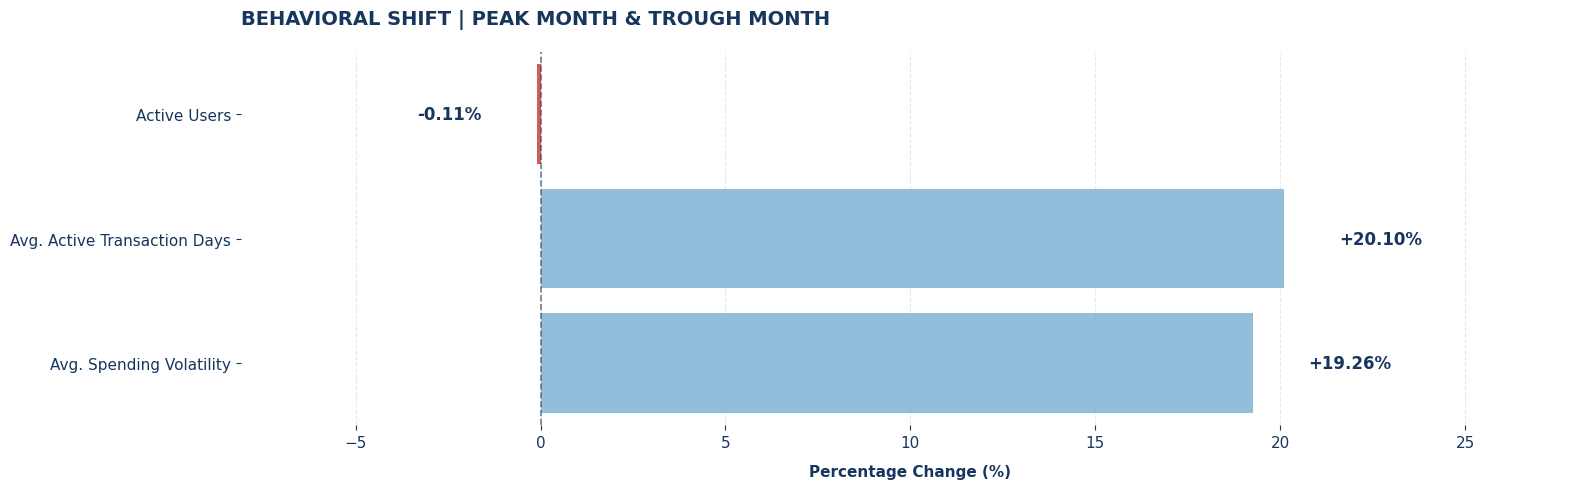

In [9]:
# ==============================================================================
# STEP 2.2B: BEHAVIORAL SHIFT VERIFICATION (CONSUMER-MONTH LEVEL) - VISUALIZED FOR PPT
# METRICS: Active Transaction Days & Spending Volatility
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ------------------------------------------------------------------------------
# 1. Synchronize Timeline
# ------------------------------------------------------------------------------
df_health['month'] = pd.to_datetime(
    df_health['analysis_month']
).dt.month

# ------------------------------------------------------------------------------
# 2. Extract Consumer-Level Metrics
# ------------------------------------------------------------------------------
cons_drivers = df_health.groupby('month').agg(
    active_users=('consumer_id', 'nunique'),
    avg_active_days=('active_transaction_days', 'mean'),
    avg_volatility=('spending_volatility', 'mean')
)

# ------------------------------------------------------------------------------
# 3. Compare Peak Month vs. Trough Month
# ------------------------------------------------------------------------------
compare_cons = cons_drivers.loc[[peak_m, trough_m]].T

compare_cons['Delta (%)'] = (
    (compare_cons[peak_m] - compare_cons[trough_m])
    / compare_cons[trough_m] * 100
)

# ------------------------------------------------------------------------------
# 4. Standardize Metric Names
# ------------------------------------------------------------------------------
compare_cons.index = [
    'Active Users',
    'Avg. Active Transaction Days',
    'Avg. Spending Volatility'
]

# Order columns: Delta (%) first, then Peak Month, then Trough Month
compare_cons_final = compare_cons[
    ['Delta (%)', peak_m, trough_m]
]

# Loại bỏ tên trục chỉ mục để góc trên bên trái trống hoàn toàn
compare_cons_final.index.name = None
compare_cons_final.columns.name = None

# ------------------------------------------------------------------------------
# 5. Styled Table (English Localization)
# ------------------------------------------------------------------------------
styled_table = (
    compare_cons_final.style
    .format({
        'Delta (%)': '{:,.2f}%',
        peak_m: '{:,.2f}',
        trough_m: '{:,.2f}'
    })
    .set_caption(
        f"BEHAVIORAL SHIFT | PEAK MONTH vs TROUGH MONTH"
    )
    .set_table_styles([
        # --- Khử hoàn toàn màu nền và viền của ô trống góc trên bên trái (blank) ---
        {
            'selector': 'th.blank',
            'props': [
                ('background-color', 'transparent !important'),
                ('border', 'none !important')
            ]
        },
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-family', 'Arial, sans-serif'),
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('color', '#17365D'),
                ('text-align', 'left'),
                ('padding', '12px 0px 10px 0px'),
                ('letter-spacing', '0.3px')
            ]
        },
        {
            'selector': 'th.col_heading',
            'props': [
                ('background-color', '#17365D'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('border', '1px solid #D9E2F3'),
                ('padding', '10px 14px'),
                ('font-size', '13px')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('color', '#17365D'),
                ('border', '1px solid #D9E2F3'),
                ('padding', '9px 14px'),
                ('font-size', '13px')
            ]
        },
        {
            'selector': 'th.row_heading',
            'props': [
                ('background-color', '#EAF2F8'),
                ('color', '#17365D'),
                ('font-weight', 'bold'),
                ('text-align', 'left'),
                ('border', '1px solid #D9E2F3'),
                ('padding', '9px 14px')
            ]
        }
    ])
    .set_properties(
        subset=[peak_m, trough_m],
        **{
            'font-weight': 'bold',
            'text-align': 'right'
        }
    )
    .set_properties(
        subset=['Delta (%)'],
        **{
            'font-weight': 'bold',
            'color': '#1F4E79',
            'background-color': '#D9EAF7',
            'text-align': 'right'
        }
    )
    .set_properties(
        **{
            'vertical-align': 'middle'
        }
    )
    .set_table_attributes(
        'style="border-collapse:collapse; '
        'width:100%; '
        'font-family:Arial, sans-serif; '
        'border:1px solid #B4C7E7;"'
    )
)

display(styled_table)
print("\n")

# ==============================================================================
# 6. PPT VISUALIZATION (WIDE CANVAS - ENG ONLY)
# ==============================================================================
plt.figure(figsize=(16, 5))

# Extract delta column to plot horizontally
plot_data = compare_cons['Delta (%)'].reset_index()
plot_data.columns = ['Metric', 'Delta (%)']

# Consistent palettes: positive = #85c1e9 (Light Blue), negative = #e74c3c
colors = ['#e74c3c' if x < 0 else '#85c1e9' for x in plot_data['Delta (%)']]

ax = sns.barplot(data=plot_data, x='Delta (%)', y='Metric', palette=colors, hue='Metric', legend=False)

# Base line at 0%
plt.axvline(0, color='#34495e', linestyle='--', linewidth=1.2, alpha=0.7)

# Add data labels directly onto the bars using the identical #17365D dark blue
for index, row in plot_data.iterrows():
    val = row['Delta (%)']
    align = 'right' if val < 0 else 'left'
    offset = -1.5 if val < 0 else 1.5
    ax.text(val + offset, index, f"{val:+.2f}%",
            va='center', ha=align, fontweight='bold', fontsize=12, color='#17365D')

# Set English Title exactly as requested, without the redundant word "month"
plt.title('BEHAVIORAL SHIFT | PEAK MONTH & TROUGH MONTH',
          fontweight='bold', fontsize=14, color='#17365D', pad=20, loc='left')

plt.xlabel('Percentage Change (%)', fontweight='bold', fontsize=11, labelpad=10, color='#17365D')
plt.ylabel('', fontsize=11)
plt.xlim(plot_data['Delta (%)'].min() - 8, plot_data['Delta (%)'].max() + 8)

# Standardize tick parameter colors to match #17365D brand identity
ax.tick_params(colors='#17365D', labelsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

> **Mardown**
- Active Users remained essentially flat (−0.11%), while Avg. Active Transaction Days rose 20.10% and Avg. Spending Volatility increased 19.26%. The peak month reflects deeper engagement, not user-base expansion, with users transacting more frequently but exhibiting less consistent spending patterns.

In [10]:
# ==============================================================================
# BI-MASTER PROTOCOL: GENERATE C-LEVEL INSIGHT TABLE (SLIDE-READY)
# ==============================================================================
from IPython.display import display, HTML

html_table = """
<style>
    /* 1. Bảng màu chủ đạo & 2. Quy chuẩn Kiểu chữ (Typography) */
    .bi-master-container {
        font-family: Arial, sans-serif;
        width: 100%;
    }
    .bi-caption {
        color: #17365D;
        font-size: 17px;
        font-weight: bold;
        text-align: left;
        padding-bottom: 12px;
    }
    table.bi-table {
        border-collapse: collapse;
        width: 100%;
        color: #17365D;
        font-size: 13px;
        border: 1px solid #B4C7E7;
    }
    /* 3. Định dạng số & Bố cục */
    table.bi-table th {
        background-color: #17365D;
        color: #FFFFFF;
        padding: 10px 14px;
        text-align: left;
        border: 1px solid #B4C7E7;
    }
    table.bi-table td {
        padding: 9px 14px;
        border: 1px solid #B4C7E7;
        text-align: left;
        line-height: 1.5;
    }
    table.bi-table td.row-header {
        background-color: #EAF2F8;
        font-weight: bold;
        width: 32%;
    }
    table.bi-table td.highlight-cell {
        background-color: #D9EAF7;
    }
    .metric-bold {
        font-weight: bold;
        color: #1F4E79;
    }
</style>

<div class="bi-master-container">
    <div class="bi-caption">DECOMPOSITION OF SPENDING DRIVERS: PEAK MONTH BEHAVIORAL SHIFTS</div>
    <table class="bi-table">
        <thead>
            <tr>
                <th>Strategic Assertion (Business Insight)</th>
                <th>Quantitative Evidence & Behavioral Translation</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td class="row-header">Structural Shift to High-Frequency Micro-Purchasing</td>
                <td class="highlight-cell">
                    Total Spend surged by <span class="metric-bold">179.89%</span> purely as a function of exploding Transaction Volume (<span class="metric-bold">+187.33%</span>), completely diverging from the marginal contractions in both Average (<span class="metric-bold">−2.59%</span>) and Median (<span class="metric-bold">−1.66%</span>) Ticket Sizes. Behaviorally, this structural shift indicates the revenue uplift is driven by high-frequency, fragmented purchasing rather than premium or bulk buying.
                </td>
            </tr>
            <tr>
                <td class="row-header">Growth via Deepened Cohort Engagement</td>
                <td class="highlight-cell">
                    Active Users remained essentially flat (<span class="metric-bold">−0.11%</span>), while Avg. Active Transaction Days rose <span class="metric-bold">20.10%</span>. The peak month reflects intensified engagement from the existing user base rather than market expansion, as retained customers transacted significantly more often.
                </td>
            </tr>
            <tr>
                <td class="row-header">Elevated Budget Volatility & Erratic Spending</td>
                <td class="highlight-cell">
                    Despite the massive revenue surge, Avg. Spending Volatility increased by <span class="metric-bold">19.26%</span>. This reveals that peak-month consumption is characterized by concentrated, highly erratic spending bursts rather than evenly distributed, sustainable daily expenditures.
                </td>
            </tr>
        </tbody>
    </table>
</div>
"""

# Render bảng trực tiếp trên Google Colab
display(HTML(html_table))

Strategic Assertion (Business Insight),Quantitative Evidence & Behavioral Translation
Structural Shift to High-Frequency Micro-Purchasing,"Total Spend surged by 179.89% purely as a function of exploding Transaction Volume (+187.33%), completely diverging from the marginal contractions in both Average (−2.59%) and Median (−1.66%) Ticket Sizes. Behaviorally, this structural shift indicates the revenue uplift is driven by high-frequency, fragmented purchasing rather than premium or bulk buying."
Growth via Deepened Cohort Engagement,"Active Users remained essentially flat (−0.11%), while Avg. Active Transaction Days rose 20.10%. The peak month reflects intensified engagement from the existing user base rather than market expansion, as retained customers transacted significantly more often."
Elevated Budget Volatility & Erratic Spending,"Despite the massive revenue surge, Avg. Spending Volatility increased by 19.26%. This reveals that peak-month consumption is characterized by concentrated, highly erratic spending bursts rather than evenly distributed, sustainable daily expenditures."


#**STAGE 3: Category Behavior & Ticket Size Analysis**

## 3.1: Tìm top danh mục

In [ ]:
# ==============================================================================
# GIAI ĐOẠN 3: CATEGORY BEHAVIOR & TICKET SIZE ANALYSIS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
from IPython.display import display, HTML

# Khóa tất cả các cảnh báo hệ thống từ Python và các thư viện bên thứ ba
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Cấu hình phong cách biểu đồ đồng bộ tránh lỗi font hệ thống
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'sans-serif'],
    'text.color': '#17365D',
    'axes.labelcolor': '#17365D',
    'xtick.color': '#17365D',
    'ytick.color': '#17365D'
})

# ------------------------------------------------------------------------------
# BƯỚC 3.1: NHẬN DIỆN DANH MỤC A & B (TOÀN BỘ 14 DANH MỤC)
# ------------------------------------------------------------------------------
cat_summary = df_trans.groupby('spending_category')['spend_amount_vnd'].agg(
    total_count='count',
    total_volume='sum'
).reset_index()

# Sắp xếp để trực quan hóa đẹp mắt
cat_summary_count = cat_summary.sort_values(by='total_count', ascending=False)
cat_summary_volume = cat_summary.sort_values(by='total_volume', ascending=False)

cat_A = cat_summary_count.iloc[0]['spending_category']
cat_B = cat_summary_volume.iloc[0]['spending_category']

# --- TRỰC QUAN HÓA TOÀN BỘ 14 BIẾN ĐỂ XÁC ĐỊNH DANH MỤC A, B ---
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))

    # 1. Biểu đồ Tần suất Giao dịch (Count)
    sns.barplot(data=cat_summary_count, x='total_count', y='spending_category',
                palette=['#17365D' if x == cat_A else '#B4C7E7' for x in cat_summary_count['spending_category']],
                ax=axes[0], hue='spending_category', legend=False)
    axes[0].set_title('SPENDING CATEGORIES BY TRANSACTION FREQUENCY (transaction count)', fontsize=13, fontweight='bold', color='#17365D', pad=15)
    axes[0].set_xlabel('Transaction Count', fontsize=11, color='#17365D')
    axes[0].set_ylabel('', fontsize=11)
    axes[0].tick_params(colors='#17365D')
    sns.despine(ax=axes[0])

    # Thêm data labels cho Plot 1
    for i, val in enumerate(cat_summary_count['total_count']):
        axes[0].text(val, i, f" {val:,}", va='center', ha='left', fontsize=10, fontweight='bold', color='#17365D')

    # 2. Biểu đồ Tổng dòng tiền chi tiêu (Volume)
    sns.barplot(data=cat_summary_volume, x='total_volume', y='spending_category',
                palette=['#85c1e9' if x == cat_B else '#B4C7E7' for x in cat_summary_volume['spending_category']],
                ax=axes[1], hue='spending_category', legend=False)
    axes[1].set_title('SPENDING CATEGORIES BY TOTAL SPEND AMOUNT (total spend volume)', fontsize=13, fontweight='bold', color='#17365D', pad=15)
    axes[1].set_xlabel('Total Spend (VND)', fontsize=11, color='#17365D')
    axes[1].set_ylabel('', fontsize=11)
    axes[1].tick_params(colors='#17365D')
    sns.despine(ax=axes[1])

    # Thêm data labels cho Plot 2
    for i, val in enumerate(cat_summary_volume['total_volume']):
        axes[1].text(val, i, f" {val/1e9:,.1f}B", va='center', ha='left', fontsize=10, fontweight='bold', color='#17365D')

    plt.tight_layout()
    plt.show()

print(f"[ĐỊNH DANH THÀNH CÔNG] Danh mục A (Top Tần suất - Count): {cat_A}")
print(f"[ĐỊNH DANH THÀNH CÔNG] Danh mục B (Top Dòng tiền - Volume): {cat_B}\n")

# ------------------------------------------------------------------------------
# BƯỚC 3.2: TÍNH TOÁN CÁC CHỈ SỐ PHÂN PHỐI & TRÌNH BÀY BẢNG CHUẨN HTML
# ------------------------------------------------------------------------------
df_AB = df_trans[df_trans['spending_category'].isin([cat_A, cat_B])]

def calc_iqr(x): return x.quantile(0.75) - x.quantile(0.25)

metrics_AB = df_AB.groupby('spending_category')['spend_amount_vnd'].agg(
    mean_val='mean',
    median_val='median',
    iqr_val=calc_iqr,
    skew_val='skew'
).reset_index()

html_metrics = f"""
<style>
    .bi3-table {{ width: 100%; border-collapse: collapse; font-family: Arial, sans-serif; font-size: 13px; color: #17365D; border: 1px solid #B4C7E7; }}
    .bi3-table caption {{ color: #17365D; font-size: 16px; font-weight: bold; text-align: left; padding-bottom: 12px; }}
    .bi3-table th {{ background-color: #17365D; color: #FFFFFF; padding: 10px 14px; border: 1px solid #B4C7E7; text-align: left; font-weight: bold; }}
    .bi3-table td {{ padding: 10px 14px; border: 1px solid #B4C7E7; text-align: left; vertical-align: middle; }}
    .bi3-table .row-header {{ background-color: #EAF2F8; font-weight: bold; width: 30%; }}
    .bi3-table .highlight {{ background-color: #D9EAF7; font-weight: bold; text-align: right; }}
    .bi3-table .num-cell {{ text-align: right; font-weight: bold; }}
</style>
<table class="bi3-table">
    <caption>TICKET SIZE DISTRIBUTION ANALYSIS: CATEGORY A VS CATEGORY B</caption>
    <thead>
        <tr>
            <th>Spending Category</th>
            <th class="num-cell">Mean Ticket Size (VND)</th>
            <th class="num-cell">Median Ticket Size (Q2 - VND)</th>
            <th class="num-cell">Interquartile Range (IQR - VND)</th>
            <th class="num-cell">Skewness Coeff. (Skew)</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td class="row-header">{metrics_AB.iloc[0]['spending_category']}</td>
            <td class="num-cell">{metrics_AB.iloc[0]['mean_val']:,.0f}</td>
            <td class="num-cell">{metrics_AB.iloc[0]['median_val']:,.0f}</td>
            <td class="num-cell">{metrics_AB.iloc[0]['iqr_val']:,.0f}</td>
            <td class="highlight">{metrics_AB.iloc[0]['skew_val']:.4f}</td>
        </tr>
        <tr>
            <td class="row-header">{metrics_AB.iloc[1]['spending_category']}</td>
            <td class="num-cell">{metrics_AB.iloc[1]['mean_val']:,.0f}</td>
            <td class="num-cell">{metrics_AB.iloc[1]['median_val']:,.0f}</td>
            <td class="num-cell">{metrics_AB.iloc[1]['iqr_val']:,.0f}</td>
            <td class="highlight">{metrics_AB.iloc[1]['skew_val']:.4f}</td>
        </tr>
    </tbody>
</table>
"""
display(HTML(html_metrics))
print("\n")

# --- BỔ SUNG: BIỂU ĐỒ BOXPLOT PHÂN TÍCH OUTLIERS & PHÂN PHỐI ---
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plt.figure(figsize=(14, 5))
    # Sử dụng log-scale cho trục x để hiển thị rõ sự khác biệt của outliers lớn ở phía đuôi phải
    ax_box = sns.boxplot(data=df_AB, x='spend_amount_vnd', y='spending_category',
                         palette=['#17365D', '#85c1e9'], hue='spending_category', legend=False)

    plt.title('TICKET SIZE DISTRIBUTION & OUTLIERS (Log Scale)', fontweight='bold', fontsize=13, color='#17365D', pad=15, loc='left')
    plt.xlabel('Spend Amount (VND) - Log Scale', fontweight='bold', color='#17365D')
    plt.ylabel('')
    ax_box.set_xscale('log')
    ax_box.tick_params(colors='#17365D', labelsize=11)
    sns.despine()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# BƯỚC 3.3: THUẬT TOÁN ĐỐI SOÁT TỶ LỆ KHOẢNG CÁCH & KẾT LUẬN CHI TIẾT
# ------------------------------------------------------------------------------
mean_A = metrics_AB.loc[metrics_AB['spending_category'] == cat_A, 'mean_val'].values[0]
mean_B = metrics_AB.loc[metrics_AB['spending_category'] == cat_B, 'mean_val'].values[0]
median_A = metrics_AB.loc[metrics_AB['spending_category'] == cat_A, 'median_val'].values[0]
median_B = metrics_AB.loc[metrics_AB['spending_category'] == cat_B, 'median_val'].values[0]

mean_ratio = mean_B / mean_A
median_ratio = median_B / median_A
ratio_gap = abs(mean_ratio - median_ratio)

# Vẽ biểu đồ đối soát trực quan tỉ lệ khoảng cách giữa Mean & Median
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plt.figure(figsize=(10, 4))
    ratio_df = pd.DataFrame({
        'Metric Type': ['Mean Ratio (B/A)', 'Median Ratio (B/A)'],
        'Ratio Value': [mean_ratio, median_ratio]
    })

    ax_ratio = sns.barplot(data=ratio_df, x='Ratio Value', y='Metric Type',
                            palette=['#17365D', '#85c1e9'], hue='Metric Type', legend=False)
    plt.axvline(1.0, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.8)

    for i, val in enumerate(ratio_df['Ratio Value']):
        ax_ratio.text(val + 0.05, i, f"{val:.2f}x", va='center', ha='left', fontweight='bold', fontsize=12, color='#17365D')

    plt.title('SCALE RATIO GAP: MEAN VS MEDIAN RATIOS (B / A)', fontweight='bold', fontsize=13, color='#17365D', pad=15, loc='left')
    plt.xlabel('Multiplier Scale', fontweight='bold', color='#17365D')
    plt.ylabel('')
    plt.xlim(0, max(mean_ratio, median_ratio) + 0.5)
    ax_ratio.tick_params(colors='#17365D', labelsize=11)
    sns.despine()
    plt.tight_layout()
    plt.show()

# Thuật toán sinh kết luận tự động dựa trên biên độ chênh lệch
if ratio_gap > 0.1:
    audit_result = (
        f"Phát hiện mức độ lệch khoảng cách đáng kể là <b>{ratio_gap:.2f}x</b> giữa Mean Ratio ({mean_ratio:.2f}x) và Median Ratio ({median_ratio:.2f}x). "
        f"Điều này chứng minh phân phối quy mô giỏ hàng của danh mục <b>{cat_B}</b> chịu tác động mạnh bởi các giao dịch Outliers cực lớn, "
        f"thổi phồng giá trị trung bình (Mean) vượt xa quy mô giỏ hàng cốt lõi thực tế (Median)."
    )
else:
    audit_result = (
        f"Mức độ lệch giữa Mean Ratio ({mean_ratio:.2f}x) và Median Ratio ({median_ratio:.2f}x) là không đáng kể (<b>{ratio_gap:.2f}x</b>). "
        f"Phân phối giá trị giỏ hàng giữa hai nhóm có sự dịch chuyển tuyến tính đồng đều, không bị tác động nhiễu đột biến bởi outliers."
    )

html_conclusion = f"""
<div style="
    font-family: Arial, sans-serif;
    border-left: 5px solid #17365D;
    background-color: #F4F8FC;
    padding: 15px 20px;
    border-radius: 4px;
    color: #17365D;
    margin-top: 20px;
    line-height: 1.6;
">
    <h4 style="margin-top: 0; margin-bottom: 8px; font-weight: bold; text-transform: uppercase; font-size: 14px; letter-spacing: 0.3px;">
       CHECK
    </h4>
    <p style="margin: 0; font-size: 13px;">
        {audit_result}
    </p>
</div>
"""
display(HTML(html_conclusion))

> **Markdown**

- Category Polarization: Fuel & Transport acts as the primary engagement hook (188,029 transactions), whereas Supermarket & Grocery serves as the core revenue anchor (513.8B VND in total spend volume)

- Supermarket revenue is driven by high-value, variable bulk purchasing, sharply contrasting with the highly predictable, routine micro-spending of Transport: Supermarket spending demands significantly higher liquidity, exhibiting a 1.67x Median ticket size premium (2.62M vs 1.57M VND). Furthermore, Supermarket's heavy right-skewness (1.09 Skew) and wide dispersion (1.41M VND IQR) confirm the presence of extreme high-value outlier purchases, whereas Transport remains rigidly symmetric and stable (0.26 Skew, 521K VND IQR).

- Strategic Dual-Engine: Transport creates recurring platform interaction (Habit Anchor), while Supermarket delivers primary balance utilization (Revenue Engine)

## 3.2 Phân tích hành vi tiêu dùng theo tháng của khách hàng đối với 2 danh mục này

In [ ]:
# ==============================================================================
# BƯỚC 3.2: KIỂM CHỨNG & ĐÁNH GIÁ TẬP TRUNG (CONSUMER-MONTH LEVEL)
# LƯỚI BẢO VỆ: Khớp nối dữ liệu 2 level bằng khóa [consumer_id, month].
# TƯ DUY TỐI ƯU: Tránh dùng apply/lambda trên chuỗi string. Dùng ma trận boolean
# (is_A, is_B) và .groupby().max() để ép kiểu dữ liệu siêu tốc O(N).
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# 1. Tái xác định danh mục A & B từ Bước trước (để đảm bảo tính độc lập của cell)
cat_summary = df_trans.groupby('spending_category')['spend_amount_vnd'].agg(count='count', volume='sum')
cat_A = cat_summary['count'].idxmax()  # Top Tần suất
cat_B = cat_summary['volume'].idxmax() # Top Dòng tiền

# 2. Tạo cờ nhị phân (Binary Flags) xác định khách hàng có mua A/B trong tháng
df_trans['is_A'] = (df_trans['spending_category'] == cat_A)
df_trans['is_B'] = (df_trans['spending_category'] == cat_B)

user_cat_flags = df_trans.groupby(['consumer_id', 'transaction_month'])[['is_A', 'is_B']].max().reset_index()

# 3. Đồng bộ trục thời gian và Merge với df_health
df_health['month'] = pd.to_datetime(df_health['analysis_month']).dt.month
df_cross = df_health.merge(user_cat_flags, left_on=['consumer_id', 'month'],
                           right_on=['consumer_id', 'transaction_month'], how='inner')

# 4. Tính toán Chỉ số Tập trung (Penetration & Behavioral Metrics)
total_c_months = len(df_cross)
metrics = []

for cat_name, flag_col in [(cat_A, 'is_A'), (cat_B, 'is_B')]:
    subset = df_cross[df_cross[flag_col]]
    metrics.append({
        'Category': cat_name,
        'Penetration (%)': (len(subset) / total_c_months) * 100,
        'Avg_Active_Days': subset['active_transaction_days'].mean(),
        'Avg_Category_Diversity': subset['category_diversity'].mean()
    })

df_metrics = pd.DataFrame(metrics)

# --- HIỂN THỊ BẢNG HTML CHUẨN ĐỒNG NHẤT VỚI BRAND THEME ---
html_metrics_32 = f"""
<style>
    .bi32-table {{ width: 100%; border-collapse: collapse; font-family: Arial, sans-serif; font-size: 13px; color: #17365D; border: 1px solid #B4C7E7; margin-bottom: 15px; }}
    .bi32-table caption {{ color: #17365D; font-size: 16px; font-weight: bold; text-align: left; padding-bottom: 12px; letter-spacing: 0.3px; }}
    .bi32-table th {{ background-color: #17365D; color: #FFFFFF; padding: 10px 14px; border: 1px solid #B4C7E7; text-align: left; font-weight: bold; }}
    .bi32-table td {{ padding: 10px 14px; border: 1px solid #B4C7E7; text-align: left; vertical-align: middle; }}
    .bi32-table .row-header {{ background-color: #EAF2F8; font-weight: bold; width: 35%; }}
    .bi32-table .highlight {{ background-color: #D9EAF7; font-weight: bold; text-align: right; }}
    .bi32-table .num-cell {{ text-align: right; font-weight: bold; }}
</style>
<table class="bi32-table">
    <caption>CROSS-LEVEL BEHAVIORAL CONCENTRATION AUDIT</caption>
    <thead>
        <tr>
            <th>Customer Transaction Category</th>
            <th class="num-cell">Penetration (%)</th>
            <th class="num-cell">Avg. Active Days / Month</th>
            <th class="num-cell">Avg. Spending Category Diversity</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td class="row-header">{df_metrics.iloc[0]['Category']} (Customer Base)</td>
            <td class="highlight">{df_metrics.iloc[0]['Penetration (%)']:.2f}%</td>
            <td class="num-cell">{df_metrics.iloc[0]['Avg_Active_Days']:.2f}</td>
            <td class="num-cell">{df_metrics.iloc[0]['Avg_Category_Diversity']:.2f}</td>
        </tr>
        <tr>
            <td class="row-header">{df_metrics.iloc[1]['Category']} (Customer Base)</td>
            <td class="highlight">{df_metrics.iloc[1]['Penetration (%)']:.2f}%</td>
            <td class="num-cell">{df_metrics.iloc[1]['Avg_Active_Days']:.2f}</td>
            <td class="num-cell">{df_metrics.iloc[1]['Avg_Category_Diversity']:.2f}</td>
        </tr>
    </tbody>
</table>
"""
display(HTML(html_metrics_32))

print("? BI-MASTER INSIGHT: A category with higher penetration indicates broader customer adoption.")
print("? If Avg_Category_Diversity is low -> Customers use the app mainly for that specific purpose, then exit (Hit & Run).")

# ==============================================================================
# TRỰC QUAN HÓA THEO THEME.PDF (UNIFIED DESIGN & BRAND STYLE GUIDE)
# Cấu hình đổi từ 1x2 (ngang) sang 2x1 (dọc chồng lên nhau) để tránh chồng lấn diện tích
# ==============================================================================
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial'],
    'text.color': '#17365D', 'axes.labelcolor': '#17365D',
    'xtick.color': '#17365D', 'ytick.color': '#17365D'
})

fig, axes = plt.subplots(2, 1, figsize=(12, 11))

# --- PLOT 1: TỶ LỆ THÂM NHẬP (PENETRATION RATE) ---
# Thêm nhãn tên rõ ràng cho biểu đồ vẽ
df_metrics['Chart_Label'] = df_metrics['Category'] + "\n(Customer Base)"

sns.barplot(data=df_metrics, x='Chart_Label', y='Penetration (%)',
            palette=['#17365D', '#B4C7E7'], ax=axes[0])

axes[0].set_title('CUSTOMER TRANSACTION PENETRATION RATE',
                  fontsize=13, fontweight='bold', loc='left', pad=12)
axes[0].set_ylabel('Customer Penetration (%)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='both', labelsize=11)
sns.despine(ax=axes[0])
axes[0].grid(axis='y', color='#D9E2F3', linestyle='-', linewidth=1, alpha=0.3)

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold',
                     color='#17365D', xytext=(0, 5), textcoords='offset points')

# --- PLOT 2: BẮT CẶP HÀNH VI (ACTIVE DAYS VS CATEGORY DIVERSITY) ---
plot_data = df_metrics[['Chart_Label', 'Avg_Active_Days', 'Avg_Category_Diversity']].melt(
    id_vars='Chart_Label', var_name='Metric', value_name='Score'
)

# Render Chart
sns.barplot(data=plot_data, x='Chart_Label', y='Score', hue='Metric',
            palette=['#85c1e9', '#17365D'], ax=axes[1])

axes[1].set_title('BEHAVIORAL INTERACTION PROFILE',
                  fontsize=13, fontweight='bold', loc='left', pad=12)
axes[1].set_ylabel('Average Value', fontsize=11, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='both', labelsize=11)
sns.despine(ax=axes[1])
axes[1].grid(axis='y', color='#D9E2F3', linestyle='-', linewidth=1, alpha=0.3)
axes[1].axhline(0, color='#34495e', linestyle='--', linewidth=1.2, alpha=0.7)

# Cấu hình Legend nằm góc trên bên phải của biểu đồ dưới nhưng chếch ra ngoài rìa để thoáng đẹp
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ['Active Days / Month', 'Spending Category Diversity'],
               loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=11)

for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold',
                     color='#17365D', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

> **Mardown**
- The behavioral divergence between these categories stems from universal consumer mental accounting, not from isolated or distinct customer segments: Cross-level validation confirms that both categories achieve near-absolute market penetration (98.67% and 99.68%) and identically high engagement rhythm (~28.7 active days/month). This proves they are daily foundational habits for the entire customer base, demonstrating how the same users intuitively switch between high-frequency micro-transactions (Transport) and high-value planned shopping (Supermarket).

# **STAGE 4: SPATIAL & DIGITAL ADOPTION GAP**

## 4.1 Thiết lập Điểm neo và Định vị Vùng trũng

In [ ]:
# ==============================================================================
# 4.1
# TƯ DUY TỐI ƯU: Sử dụng Vectorization để lọc Digital Channels và tính toán Median
# ==============================================================================
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# 1. Định nghĩa & Tính Tỷ trọng Digital trung bình toàn quốc (Global Digital Ratio)
# Theo từ điển dữ liệu, Digital = Tất cả phương thức TRỪ 'POS'
df_trans['is_digital'] = df_trans['transaction_channel'] != 'POS'
df_trans['digital_spend'] = df_trans['spend_amount_vnd'] * df_trans['is_digital']

global_total_spend = df_trans['spend_amount_vnd'].sum()
global_digital_spend = df_trans['digital_spend'].sum()
global_digital_ratio = (global_digital_spend / global_total_spend) * 100

# 2. Gom nhóm theo 34 tỉnh thành và tính các chỉ số thành phần
prov_summary = df_trans.groupby('province_city').agg(
    total_spend=('spend_amount_vnd', 'sum'),
    digital_spend=('digital_spend', 'sum')
).reset_index()

prov_summary['digital_ratio'] = (prov_summary['digital_spend'] / prov_summary['total_spend']) * 100

# 3. Lọc tập hợp "High Volume & Low Digital Adoption"
median_prov_spend = prov_summary['total_spend'].median()

lagging_provinces = prov_summary[
    (prov_summary['total_spend'] > median_prov_spend) &
    (prov_summary['digital_ratio'] < global_digital_ratio)
].copy()

# Sắp xếp từ cao xuống thấp theo tổng chi tiêu
# (Khoảng cách chênh lệch thể hiện rõ nhất ở những tỉnh có Dòng tiền cực lớn nhưng Tỷ trọng số hóa lại nghèo nàn)
lagging_provinces = lagging_provinces.sort_values(by='total_spend', ascending=False)

# ==============================================================================
# XUẤT BẢNG HTML TUÂN THỦ TUYỆT ĐỐI "THEME.PDF" (UNIFIED TABLE STYLE GUIDE)
# ==============================================================================
rows_html = ""
for _, row in lagging_provinces.iterrows():
    rows_html += f"""
        <tr>
            <td class="row-header">{row['province_city']}</td>
            <td>{row['total_spend']:,.0f}</td>
            <td class="highlight-cell">{row['digital_ratio']:.2f}%</td>
        </tr>
    """

html_table = f"""
<style>
    .bi-master-container {{ font-family: Arial, sans-serif; width: 100%; }}
    .bi-caption {{ color: #17365D; font-size: 16px; font-weight: bold; text-align: left; padding-bottom: 12px; }}
    .bi-note {{ color: #1F4E79; font-size: 13px; font-style: italic; padding-bottom: 8px; margin-bottom: 10px; }}

    table.bi-table {{ border-collapse: collapse; width: 100%; color: #17365D; font-size: 13px; border: 1px solid #B4C7E7; }}
    table.bi-table th {{ background-color: #17365D; color: #FFFFFF; padding: 10px 14px; border: 1px solid #B4C7E7; font-weight: bold; }}
    table.bi-table td {{ padding: 9px 14px; border: 1px solid #B4C7E7; line-height: 1.5; text-align: right; }}

    /* Căn lề Header */
    table.bi-table th.col-prov {{ text-align: left; width: 35%; }}
    table.bi-table th.col-num {{ text-align: right; }}

    /* Định dạng Cột/Ô đặc thù */
    table.bi-table td.row-header {{ background-color: #EAF2F8; font-weight: bold; text-align: left; }}
    table.bi-table td.highlight-cell {{ background-color: #D9EAF7; color: #1F4E79; font-weight: bold; }}
</style>

<div class="bi-master-container">
    <div class="bi-caption">SPATIAL PROVINCES: HIGH-VOLUME LAGGING HUBS</div>
    <div class="bi-note">
        * Benchmark Metrics:<br>
        - High Volume Threshold (Median Total Spend): <b>{median_prov_spend:,.0f} VND</b><br>
        - Global Digital Ratio: <b>{global_digital_ratio:.2f}%</b>
    </div>
    <table class="bi-table">
        <thead>
            <tr>
                <th class="col-prov">Tỉnh / Thành phố (Province / City)</th>
                <th class="col-num"> Total Spend (VND)</th>
                <th class="col-num"> Digital Ratio (%)</th>
            </tr>
        </thead>
        <tbody>
            {rows_html}
        </tbody>
    </table>
</div>
"""

# Render bảng HTML
display(HTML(html_table))

Tỉnh / Thành phố (Province / City),Total Spend (VND),Digital Ratio (%)
Thành phố Hồ Chí Minh,"442,175,772,000",41.30%
Hà Nội,"267,264,508,000",40.91%
Đồng Nai,"183,072,471,000",41.35%
Lâm Đồng,"135,389,980,000",41.30%
Cần Thơ,"126,027,485,000",41.15%
Hưng Yên,"116,442,487,000",41.34%
Vĩnh Long,"106,026,604,000",41.32%
Đắk Lắk,"90,836,537,000",41.31%


##**4.2: Channel & Category Decomposition**

Metrics / Channels,Global Benchmark,Thành phố Hồ Chí Minh,Hà Nội
Total Spend (VND),"3,244,632,958,000","442,175,772,000","267,264,508,000"
Digital Ratio (%),41.46%,41.30%,40.91%
Digital Adoption Gap,0.00%,-0.17%,-0.55%
POS Share,58.54%,58.70%,59.09%
E-commerce Share,9.62%,9.76%,9.23%
Mobile App Share,7.61%,7.74%,7.40%
QR Payment Share,19.63%,19.26%,19.85%
Recurring Payment Share,4.61%,4.53%,4.43%


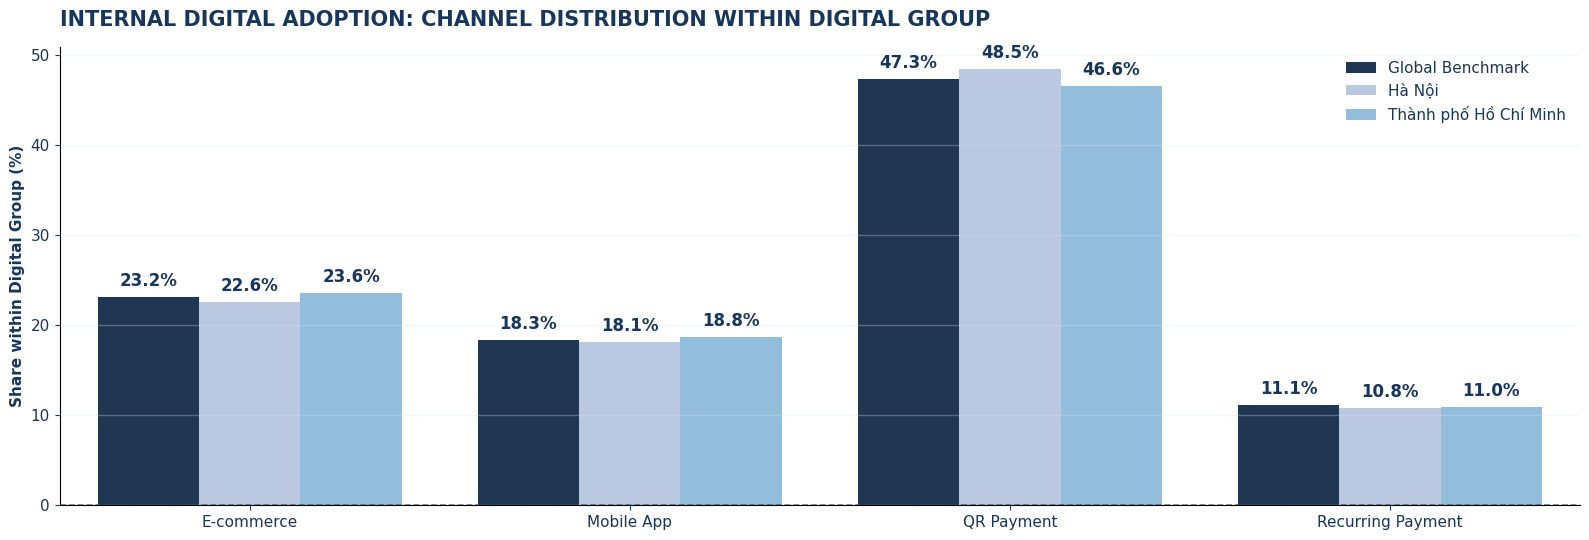

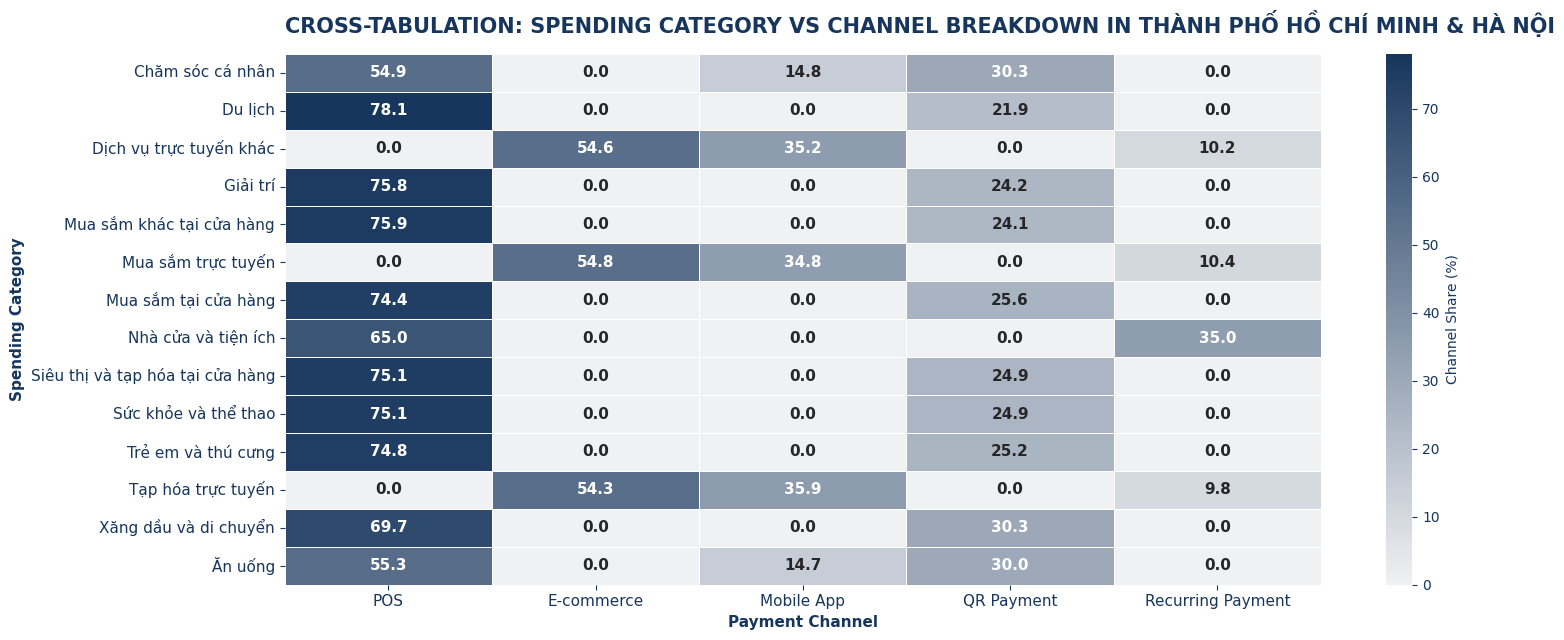

In [ ]:
# ==============================================================================
# BƯỚC 4.2: GIẢI PHẪU CƠ CẤU KÊNH & LÁT CẮT NGÀNH HÀNG (CHANNEL DECOMPOSITION)
# TƯ DUY TỐI ƯU: Tái tính toán Global Benchmark -> Lọc đúng 2 tỉnh Vùng trũng lớn nhất
# -> Xuất Bảng định lượng Gap -> Trực quan hóa Phân bổ Digital & Ma trận chéo.
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# ------------------------------------------------------------------------------
# 1. ĐỊNH VỊ 2 TỈNH SỐ HÓA THẤP CÓ TỔNG CHI TIÊU CAO NHẤT
# ------------------------------------------------------------------------------
df_trans['is_digital'] = df_trans['transaction_channel'] != 'POS'
df_trans['digital_spend'] = df_trans['spend_amount_vnd'] * df_trans['is_digital']

global_total = df_trans['spend_amount_vnd'].sum()
global_digital = df_trans['digital_spend'].sum()
global_digital_ratio = (global_digital / global_total) * 100

prov_agg = df_trans.groupby('province_city').agg(
    total_spend=('spend_amount_vnd', 'sum'),
    digital_spend=('digital_spend', 'sum')
).reset_index()
prov_agg['digital_ratio'] = (prov_agg['digital_spend'] / prov_agg['total_spend']) * 100

# Điều kiện: Spend > Median VÀ Digital Ratio < Global Benchmark
median_spend = prov_agg['total_spend'].median()
lagging_provs = prov_agg[(prov_agg['total_spend'] > median_spend) & (prov_agg['digital_ratio'] < global_digital_ratio)]

# Lọc 2 tỉnh có Tổng chi tiêu cao nhất
top2_lagging = lagging_provs.sort_values('total_spend', ascending=False).head(2)
prov_A, prov_A_spend, prov_A_dig_ratio = top2_lagging.iloc[0]['province_city'], top2_lagging.iloc[0]['total_spend'], top2_lagging.iloc[0]['digital_ratio']
prov_B, prov_B_spend, prov_B_dig_ratio = top2_lagging.iloc[1]['province_city'], top2_lagging.iloc[1]['total_spend'], top2_lagging.iloc[1]['digital_ratio']

# ------------------------------------------------------------------------------
# 2. XUẤT BẢNG HTML: DIGITAL ADOPTION GAP & CƠ CẤU KÊNH THEO THEME
# ------------------------------------------------------------------------------
df_top2 = df_trans[df_trans['province_city'].isin([prov_A, prov_B])]

glob_ch = (df_trans.groupby('transaction_channel')['spend_amount_vnd'].sum() / global_total * 100).to_dict()
prov_A_ch = (df_top2[df_top2['province_city'] == prov_A].groupby('transaction_channel')['spend_amount_vnd'].sum() / prov_A_spend * 100).to_dict()
prov_B_ch = (df_top2[df_top2['province_city'] == prov_B].groupby('transaction_channel')['spend_amount_vnd'].sum() / prov_B_spend * 100).to_dict()

gap_A = global_digital_ratio - prov_A_dig_ratio
gap_B = global_digital_ratio - prov_B_dig_ratio

def format_row(name, glob_val, a_val, b_val, is_highlight=False):
    cls = ' class="highlight-cell"' if is_highlight else ''
    return f'<tr><td class="row-header">{name}</td><td>{glob_val}</td><td{cls}>{a_val}</td><td{cls}>{b_val}</td></tr>'

html_table = f"""
<style>
    .bi-container {{ font-family: Arial, sans-serif; width: 100%; margin-bottom: 25px; }}
    .bi-caption {{ color: #17365D; font-size: 16px; font-weight: bold; text-align: left; padding-bottom: 12px; }}
    table.bi-table {{ border-collapse: collapse; width: 100%; color: #17365D; font-size: 13px; border: 1px solid #B4C7E7; }}
    table.bi-table th {{ background-color: #17365D; color: #FFFFFF; padding: 10px 14px; text-align: right; border: 1px solid #B4C7E7; font-weight: bold; }}
    table.bi-table th.col-left {{ text-align: left; width: 30%; }}
    table.bi-table td {{ padding: 9px 14px; border: 1px solid #B4C7E7; text-align: right; line-height: 1.5; }}
    table.bi-table td.row-header {{ background-color: #EAF2F8; font-weight: bold; text-align: left; }}
    table.bi-table td.highlight-cell {{ background-color: #D9EAF7; color: #1F4E79; font-weight: bold; }}
</style>
<div class="bi-container">
    <div class="bi-caption">CHANNEL DECOMPOSITION & DIGITAL ADOPTION GAP</div>
    <table class="bi-table">
        <thead>
            <tr>
                <th class="col-left">Metrics / Channels</th>
                <th>Global Benchmark</th>
                <th>{prov_A}</th>
                <th>{prov_B}</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td class="row-header">Total Spend (VND)</td>
                <td>{global_total:,.0f}</td>
                <td>{prov_A_spend:,.0f}</td>
                <td>{prov_B_spend:,.0f}</td>
            </tr>
            <tr>
                <td class="row-header">Digital Ratio (%)</td>
                <td>{global_digital_ratio:.2f}%</td>
                <td class="highlight-cell">{prov_A_dig_ratio:.2f}%</td>
                <td class="highlight-cell">{prov_B_dig_ratio:.2f}%</td>
            </tr>
            <tr>
                <td class="row-header">Digital Adoption Gap</td>
                <td>0.00%</td>
                <td class="highlight-cell">-{gap_A:.2f}%</td>
                <td class="highlight-cell">-{gap_B:.2f}%</td>
            </tr>
            {format_row('POS Share', f"{glob_ch.get('POS',0):.2f}%", f"{prov_A_ch.get('POS',0):.2f}%", f"{prov_B_ch.get('POS',0):.2f}%")}
            {format_row('E-commerce Share', f"{glob_ch.get('E-commerce',0):.2f}%", f"{prov_A_ch.get('E-commerce',0):.2f}%", f"{prov_B_ch.get('E-commerce',0):.2f}%")}
            {format_row('Mobile App Share', f"{glob_ch.get('Mobile App',0):.2f}%", f"{prov_A_ch.get('Mobile App',0):.2f}%", f"{prov_B_ch.get('Mobile App',0):.2f}%")}
            {format_row('QR Payment Share', f"{glob_ch.get('QR Payment',0):.2f}%", f"{prov_A_ch.get('QR Payment',0):.2f}%", f"{prov_B_ch.get('QR Payment',0):.2f}%")}
            {format_row('Recurring Payment Share', f"{glob_ch.get('Recurring Payment',0):.2f}%", f"{prov_A_ch.get('Recurring Payment',0):.2f}%", f"{prov_B_ch.get('Recurring Payment',0):.2f}%")}
        </tbody>
    </table>
</div>
"""
display(HTML(html_table))

# ------------------------------------------------------------------------------
# 3. TRỰC QUAN HÓA: TỶ TRỌNG PHÂN BỔ BÊN TRONG LÒNG NHÓM DIGITAL & CROSSTAB
# ------------------------------------------------------------------------------
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial'],
    'text.color': '#17365D', 'axes.labelcolor': '#17365D',
    'xtick.color': '#17365D', 'ytick.color': '#17365D'
})

# --- PLOT 1: INTERNAL DIGITAL CHANNEL DISTRIBUTION ---
digital_channels = ['E-commerce', 'Mobile App', 'QR Payment', 'Recurring Payment']
df_dig_global = df_trans[df_trans['transaction_channel'].isin(digital_channels)]
df_dig_top2 = df_top2[df_top2['transaction_channel'].isin(digital_channels)]

glob_dig_dist = (df_dig_global.groupby('transaction_channel')['spend_amount_vnd'].sum() / global_digital * 100).reset_index()
glob_dig_dist['Region'] = 'Global Benchmark'

prov_dig_dist = df_dig_top2.groupby(['province_city', 'transaction_channel'])['spend_amount_vnd'].sum().reset_index()
prov_dig_dist['spend_amount_vnd'] = prov_dig_dist.groupby('province_city')['spend_amount_vnd'].transform(lambda x: x / x.sum() * 100)
prov_dig_dist.rename(columns={'province_city': 'Region'}, inplace=True)

plot_data = pd.concat([glob_dig_dist, prov_dig_dist])

fig, ax1 = plt.subplots(figsize=(16, 5.5))
sns.barplot(data=plot_data, x='transaction_channel', y='spend_amount_vnd', hue='Region',
            palette=['#17365D', '#B4C7E7', '#85c1e9'], ax=ax1)

ax1.set_title('INTERNAL DIGITAL ADOPTION: CHANNEL DISTRIBUTION WITHIN DIGITAL GROUP', fontsize=15, fontweight='bold', loc='left', pad=15)
ax1.set_ylabel('Share within Digital Group (%)', fontsize=11, fontweight='bold')
ax1.set_xlabel('')
ax1.tick_params(axis='both', labelsize=11)
sns.despine(ax=ax1)
ax1.grid(axis='y', color='#D9E2F3', linestyle='-', linewidth=1, alpha=0.3)
ax1.axhline(0, color='#34495e', linestyle='--', linewidth=1.2, alpha=0.7)

for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold',
                     color='#17365D', xytext=(0, 5), textcoords='offset points')
plt.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

# --- PLOT 2: HEATMAP MA TRẬN CHÉO (CATEGORY VS CHANNEL) ---
# Cross-tabulate % Share of Channels within each Category for the 2 Lagging Provinces
crosstab_df = pd.crosstab(
    index=df_top2['spending_category'],
    columns=df_top2['transaction_channel'],
    values=df_top2['spend_amount_vnd'],
    aggfunc='sum',
    normalize='index'
) * 100

# Đẩy POS lên đầu tiên để dễ đối chiếu
cols = ['POS'] + [c for c in crosstab_df.columns if c != 'POS']
crosstab_df = crosstab_df[cols]

fig, ax2 = plt.subplots(figsize=(16, 6.5))
sns.heatmap(crosstab_df, annot=True, fmt=".1f", cmap=sns.light_palette("#17365D", as_cmap=True),
            linewidths=.5, cbar_kws={'label': 'Channel Share (%)'}, ax=ax2, annot_kws={"size": 11, "weight": "bold"})

ax2.set_title(f'CROSS-TABULATION: SPENDING CATEGORY VS CHANNEL BREAKDOWN IN {prov_A.upper()} & {prov_B.upper()}',
              fontsize=15, fontweight='bold', loc='left', pad=15)
ax2.set_ylabel('Spending Category', fontsize=11, fontweight='bold')
ax2.set_xlabel('Payment Channel', fontsize=11, fontweight='bold')
ax2.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()

## 4.3

Behavioral & Demographic Metrics,Global Benchmark,Thành phố Hồ Chí Minh,Hà Nội
Avg. Overall Engagement Score (0-100),77.8,78.0,77.7
Personal Avg. Online Spend Ratio (%),21.03%,21.26%,20.44%
Median Age (Years),48,48,52


/tmp/ipykernel_3930/2208601974.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_age_viz, x='Region', y='age',


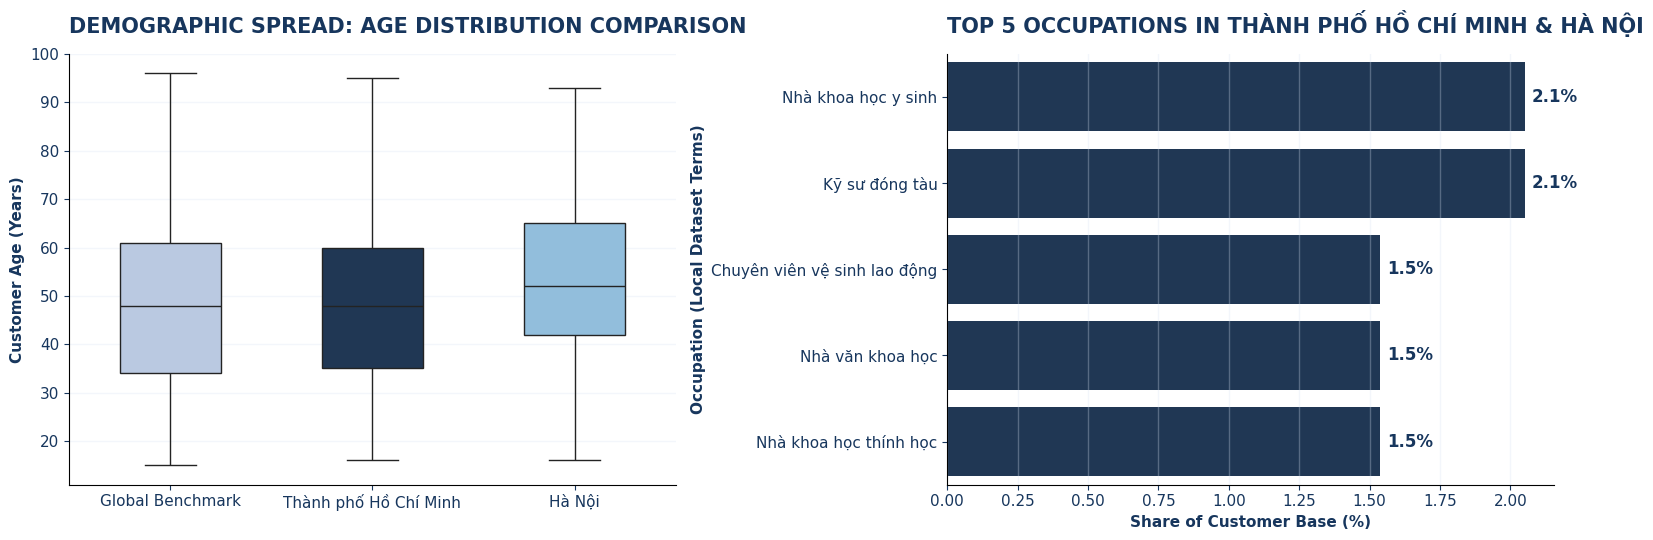


[SLIDE PITCHING]
KIỂM CHỨNG BẢN CHẤT (THE NATURE):
- Nếu 'Avg. Overall Engagement Score' của 2 tỉnh này VẪN CAO (xấp xỉ Benchmark), nhưng 'Online Spend Ratio' cực thấp:
  => Chốt luận điểm: Lỗi không nằm ở User. Khách hàng vẫn tương tác cực tốt qua app nhưng các Merchant địa phương không hỗ trợ thanh toán số (Infrastructure Bottleneck). Cần đổ ngân sách thu hút Merchant POS chuyển sang QR.
- Nếu 'Median Age' của 2 tỉnh này CAO HƠN HẲN Benchmark (Phân phối boxplot lệch lên trên), và tập trung vào các nhóm nghề nghiệp truyền thống:
  => Chốt luận điểm: Rào cản Nhân khẩu học (Demographic Hurdle). Cần chiến dịch 'Educate' công nghệ riêng cho tệp người lớn tuổi (vd: Hoàn tiền khi quẹt QR lần đầu).


In [ ]:
# ==============================================================================
# STAGE 4.3: CROSS-LEVEL VALIDATION - ENGAGEMENT & DEMOGRAPHIC PROFILING
# TƯ DUY TỐI ƯU: Truy vấn tập khách hàng tại 2 vùng trũng trực tiếp từ df_health.
# Đối soát Engagement, Online Ratio cá nhân và Cơ cấu Nhân khẩu học.
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Ghi chú: prov_A và prov_B kế thừa tự động từ Bước 4.2.
# (Nếu chạy độc lập cell này để test, hãy gỡ comment 2 dòng dưới)
# prov_A = 'Hà Nội'
# prov_B = 'Thành phố Hồ Chí Minh'

# ------------------------------------------------------------------------------
# 1. TÍNH TOÁN METRICS ĐỐI SOÁT CHÉO TỪ DF_HEALTH
# ------------------------------------------------------------------------------
glob_eng = df_health['engagement_score'].mean()
glob_online = df_health['online_spend_ratio'].mean() * 100
glob_age = df_health['age'].median()

df_prov_A = df_health[df_health['province_city'] == prov_A]
df_prov_B = df_health[df_health['province_city'] == prov_B]

a_eng, a_online, a_age = df_prov_A['engagement_score'].mean(), df_prov_A['online_spend_ratio'].mean() * 100, df_prov_A['age'].median()
b_eng, b_online, b_age = df_prov_B['engagement_score'].mean(), df_prov_B['online_spend_ratio'].mean() * 100, df_prov_B['age'].median()

# ------------------------------------------------------------------------------
# 2. XUẤT BẢNG HTML: ENGAGEMENT & DEMOGRAPHIC PROFILE THEO THEME
# ------------------------------------------------------------------------------
html_table = f"""
<style>
    .bi-container {{ font-family: Arial, sans-serif; width: 100%; margin-bottom: 25px; }}
    .bi-caption {{ color: #17365D; font-size: 16px; font-weight: bold; text-align: left; padding-bottom: 12px; text-transform: uppercase; }}
    table.bi-table {{ border-collapse: collapse; width: 100%; color: #17365D; font-size: 13px; border: 1px solid #B4C7E7; }}
    table.bi-table th {{ background-color: #17365D; color: #FFFFFF; padding: 10px 14px; text-align: right; border: 1px solid #B4C7E7; font-weight: bold; }}
    table.bi-table th.col-left {{ text-align: left; width: 35%; }}
    table.bi-table td {{ padding: 9px 14px; border: 1px solid #B4C7E7; text-align: right; line-height: 1.5; }}
    table.bi-table td.row-header {{ background-color: #EAF2F8; font-weight: bold; text-align: left; }}
    table.bi-table td.highlight-cell {{ background-color: #D9EAF7; color: #1F4E79; font-weight: bold; }}
</style>
<div class="bi-container">
    <div class="bi-caption">CONSUMER-MONTH VALIDATION: ENGAGEMENT & DEMOGRAPHIC PROFILE</div>
    <table class="bi-table">
        <thead>
            <tr>
                <th class="col-left">Behavioral & Demographic Metrics</th>
                <th>Global Benchmark</th>
                <th>{prov_A}</th>
                <th>{prov_B}</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td class="row-header">Avg. Overall Engagement Score (0-100)</td>
                <td>{glob_eng:.1f}</td>
                <td class="highlight-cell">{a_eng:.1f}</td>
                <td class="highlight-cell">{b_eng:.1f}</td>
            </tr>
            <tr>
                <td class="row-header">Personal Avg. Online Spend Ratio (%)</td>
                <td>{glob_online:.2f}%</td>
                <td class="highlight-cell">{a_online:.2f}%</td>
                <td class="highlight-cell">{b_online:.2f}%</td>
            </tr>
            <tr>
                <td class="row-header">Median Age (Years)</td>
                <td>{glob_age:.0f}</td>
                <td>{a_age:.0f}</td>
                <td>{b_age:.0f}</td>
            </tr>
        </tbody>
    </table>
</div>
"""
display(HTML(html_table))

# ------------------------------------------------------------------------------
# 3. TRỰC QUAN HÓA NHÂN KHẨU HỌC: AGE DISTRIBUTION & TOP OCCUPATIONS
# ------------------------------------------------------------------------------
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial'],
    'text.color': '#17365D', 'axes.labelcolor': '#17365D',
    'xtick.color': '#17365D', 'ytick.color': '#17365D'
})

# Chuẩn bị dữ liệu vẽ Boxplot (Age)
df_global_plot = df_health[['age']].copy()
df_global_plot['Region'] = 'Global Benchmark'

df_prov_plot = df_health[df_health['province_city'].isin([prov_A, prov_B])][['age', 'province_city']].copy()
df_prov_plot.rename(columns={'province_city': 'Region'}, inplace=True)

df_age_viz = pd.concat([df_global_plot, df_prov_plot], ignore_index=True)

# Chuẩn bị dữ liệu Barplot (Occupation) cho 2 vùng trũng
df_lagging_hubs = df_health[df_health['province_city'].isin([prov_A, prov_B])]
top_occ = df_lagging_hubs['occupation'].value_counts(normalize=True).head(5) * 100

# Khởi tạo Canvas (16, 5.5)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# --- PLOT 1: DEMOGRAPHIC AGE DISTRIBUTION ---
sns.boxplot(data=df_age_viz, x='Region', y='age',
            palette=['#B4C7E7', '#17365D', '#85c1e9'], width=0.5, ax=axes[0])

axes[0].set_title('DEMOGRAPHIC SPREAD: AGE DISTRIBUTION COMPARISON', fontsize=15, fontweight='bold', loc='left', pad=15)
axes[0].set_ylabel('Customer Age (Years)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='both', labelsize=11)
sns.despine(ax=axes[0])
axes[0].grid(axis='y', color='#D9E2F3', linestyle='-', linewidth=1, alpha=0.3)

# --- PLOT 2: TOP OCCUPATIONS IN LAGGING HUBS ---
sns.barplot(y=top_occ.index, x=top_occ.values, color='#17365D', ax=axes[1])

axes[1].set_title(f'TOP 5 OCCUPATIONS IN {prov_A.upper()} & {prov_B.upper()}', fontsize=15, fontweight='bold', loc='left', pad=15)
axes[1].set_xlabel('Share of Customer Base (%)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Occupation (Local Dataset Terms)', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=11)
sns.despine(ax=axes[1])
axes[1].grid(axis='x', color='#D9E2F3', linestyle='-', linewidth=1, alpha=0.3)

# Thêm Data Labels cho Bar Chart
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_width():.1f}%",
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=12, fontweight='bold',
                     color='#17365D', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

# BI-MASTER STRATEGY HINT:
print("\n[SLIDE PITCHING]")
print("KIỂM CHỨNG BẢN CHẤT (THE NATURE):")
print("- Nếu 'Avg. Overall Engagement Score' của 2 tỉnh này VẪN CAO (xấp xỉ Benchmark), nhưng 'Online Spend Ratio' cực thấp:")
print("  => Chốt luận điểm: Lỗi không nằm ở User. Khách hàng vẫn tương tác cực tốt qua app nhưng các Merchant địa phương không hỗ trợ thanh toán số (Infrastructure Bottleneck). Cần đổ ngân sách thu hút Merchant POS chuyển sang QR.")
print("- Nếu 'Median Age' của 2 tỉnh này CAO HƠN HẲN Benchmark (Phân phối boxplot lệch lên trên), và tập trung vào các nhóm nghề nghiệp truyền thống:")
print("  => Chốt luận điểm: Rào cản Nhân khẩu học (Demographic Hurdle). Cần chiến dịch 'Educate' công nghệ riêng cho tệp người lớn tuổi (vd: Hoàn tiền khi quẹt QR lần đầu).")